In [150]:
# Importing necessary libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest

# Task 1 — Data Loading, Merging & Deep Exploration 

## Load the Superstore Sales CSV using Pandas 

In [151]:
dataset = pd.read_csv('train.csv')

## Parse the Order Date and Ship Date columns as proper datetime objects 

In [152]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [153]:
dataset['Order Date'] = pd.to_datetime(dataset['Order Date'],format = '%d/%m/%Y')
dataset['Ship Date'] = pd.to_datetime(dataset['Ship Date'],format = '%d/%m/%Y')

print(dataset[['Order Date','Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


## Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season 

In [154]:
# Extract time features from Order Date

dataset['Year'] = dataset['Order Date'].dt.year
dataset['Month'] = dataset['Order Date'].dt.month
dataset['Month Name'] = dataset['Order Date'].dt.month_name()
dataset['Week Number'] = dataset['Order Date'].dt.isocalendar().week.astype(int)
dataset['Day of Week'] = dataset['Order Date'].dt.day_name()
dataset['Quarter'] = dataset['Order Date'].dt.quarter

# Function to assign seasons
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8,9]:
        return 'Monsoon'
    elif month in [10,11]:
        return 'Post-Monsoon'

dataset['Season'] = dataset['Month'].apply(get_season)

# Display the extracted features
dataset[['Order Date','Year','Month','Month Name',
         'Week Number','Day of Week','Quarter','Season']].head()

,Order Date,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,November,45,Wednesday,4,Post-Monsoon
1,2017-11-08,2017,11,November,45,Wednesday,4,Post-Monsoon
2,2017-06-12,2017,6,June,24,Monday,2,Monsoon
3,2016-10-11,2016,10,October,41,Tuesday,4,Post-Monsoon
4,2016-10-11,2016,10,October,41,Tuesday,4,Post-Monsoon


**Why these features are important**
- **Year :** Analyze sales growth across years
- **Month :** Detect monthly seasonality
- **Week Number :** Aggregate weekly sales and detect anomalies
- **Day of Week :** Identify weekday vs weekend sales patterns
- **Quarter :** Analyze quarterly business performance
- **Season :** Capture seasonal demand, which is useful for forecasting models like XGBoost

## Check for missing values, duplicates, and data type issues 

In [155]:
# Check missing values in each column
dataset.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

In [156]:
# Fill with the most frequent postal code for each city
dataset['Postal Code'] = dataset.groupby('City')['Postal Code'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else x.median())
)
dataset.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Year             0
Month            0
Month Name       0
Week Number      0
Day of Week      0
Quarter          0
Season           0
dtype: int64

The dataset was inspected for missing values using isnull().sum().Missing values were found in the **Postal Code** column.Since postal code is not a significant feature for sales forecasting and does not influence time-series patterns,the missing values were handled by filling them with the most frequent postal code within the corresponding city. After treatment, the dataset contained no missing values and was ready for further analysis.

In [157]:
# Number of duplicate rows
dataset.duplicated().sum()

np.int64(0)

In [158]:
# Check data types
dataset.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Month Name               object
Week Number               int64
Day of Week              object
Quarter                   int32
Season                   object
dtype: object

In [159]:
# Check numeric columns stored as strings
object_columns = dataset.select_dtypes(include = 'object').columns

object_columns

Index(['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment',
       'Country', 'City', 'State', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Month Name', 'Day of Week', 'Season'],
      dtype='object')

## Aggregate daily sales into weekly and monthly totals

In [160]:
# Aggregate sales by day 
daily_sales = (
    dataset.groupby('Order Date')['Sales']
    .sum()
    .reset_index()
    .sort_values('Order Date')
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [161]:
# Weekly sales
weekly_sales = (
    daily_sales
    .set_index('Order Date')
    .resample('W')['Sales']   # W represents weekly frequency
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [162]:
# Aggregate Monthly Sales
monthly_sales = (
    daily_sales
    .set_index('Order Date')
    .resample('ME')['Sales']  # ME(month-end) aggregates sales at the end of each month
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [163]:
print('Daily Sales Shape:',daily_sales.shape)
print('Weekly Sales Shape:',weekly_sales.shape)
print('Monthly Sales Shape:',monthly_sales.shape)

Daily Sales Shape: (1230, 2)
Weekly Sales Shape: (209, 2)
Monthly Sales Shape: (48, 2)


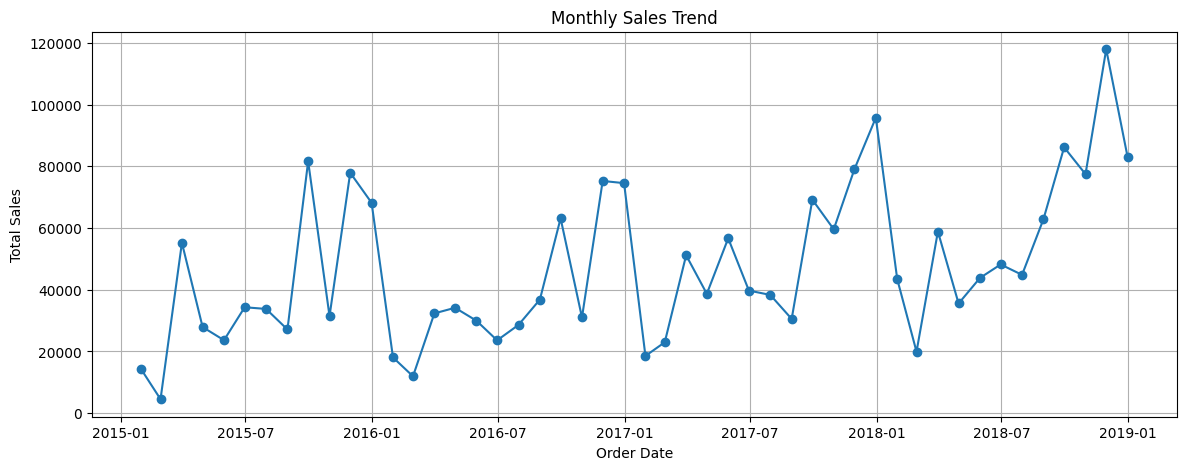

In [164]:
# Visualize the aggregated sales

plt.figure(figsize = (14,5))
plt.plot(monthly_sales['Order Date'],monthly_sales['Sales'],marker = 'o')
plt.title('Monthly Sales Trend')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.savefig('charts/Monthly_Sales_Trend.png')
plt.show()

## Answer these questions in your notebook with data to back each one: 

## Which product category generates the highest total revenue?

In [165]:
# Total revenue by category 
category_sales = (
    dataset.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending = False)
    .reset_index()
)

category_sales

,Category,Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


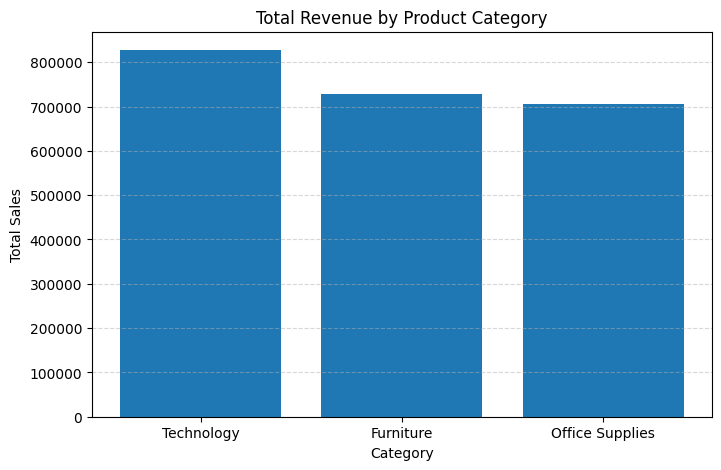

In [167]:
# visualizing the results

plt.figure(figsize = (8,5))
plt.bar(category_sales['Category'],category_sales['Sales'])
plt.title('Total Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.savefig('charts/Total_Revenue_by_Product_Category.png')
plt.show()

The **Technology** category generated the highest total revenue with sales of **827455.8730** making it the most profitable category during the analysis period.

## Which region has the most consistent sales growth over 4 years?

In [168]:
region_yearly_sales = (
    dataset.groupby(['Region','Year'])['Sales']
    .sum()
    .reset_index()
)

region_yearly_sales

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


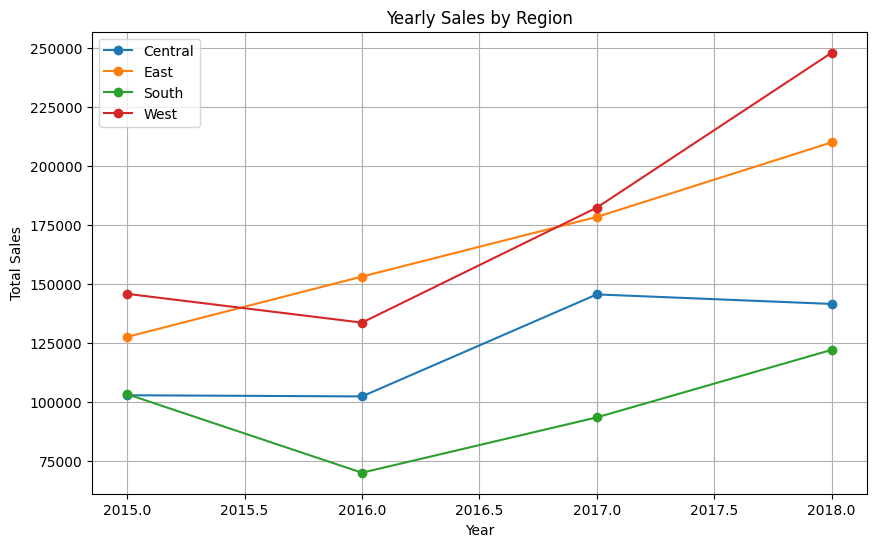

In [169]:
# Visualization

plt.figure(figsize = (10,6))

for region in region_yearly_sales['Region'].unique():
    temp = region_yearly_sales[region_yearly_sales['Region'] == region]
    plt.plot(temp['Year'], temp['Sales'], marker = 'o', label = region)

plt.title('Yearly Sales by Region')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.savefig('charts/Yearly_Sales_by_Region.png')
plt.show()

In [170]:
# Measure consistency using the Coefficient of Variation

consistency = (
    region_yearly_sales.groupby('Region')['Sales']
    .agg(['mean','std'])
)

consistency['CV'] = consistency['std'] / consistency['mean']

consistency.sort_values('CV')

# Lower CV indicates more consistent growth

,mean,std,CV
Region,,,
Central,123161.728300,23716.991355,0.192568
East,167379.681500,35260.987867,0.210665
South,97287.864750,21683.024937,0.222875
West,177554.921125,51410.399288,0.289546


The **West** region exhibited the most consistent sales growth across the four-year period, as evidenced by the lowest coefficient of variation and a steady upward trend.

## What is the average time between Order Date and Ship Date? Does it vary by region?

In [171]:
# Create shipping duration

dataset['Shipping Time (Days)'] = (
    dataset['Ship Date'] - dataset['Order Date']
).dt.days

In [172]:
# Overall average

average_shipping = dataset['Shipping Time (Days)'].mean()

print('Average Shipping Time:',round(average_shipping,2), 'days')

Average Shipping Time: 3.96 days


In [173]:
# By region

shipping_region = (
    dataset.groupby('Region')['Shipping Time (Days)']
    .mean()
    .sort_values()
    .reset_index()
)

shipping_region

,Region,Shipping Time (Days)
0,East,3.910233
1,West,3.930255
2,South,3.961202
3,Central,4.065876


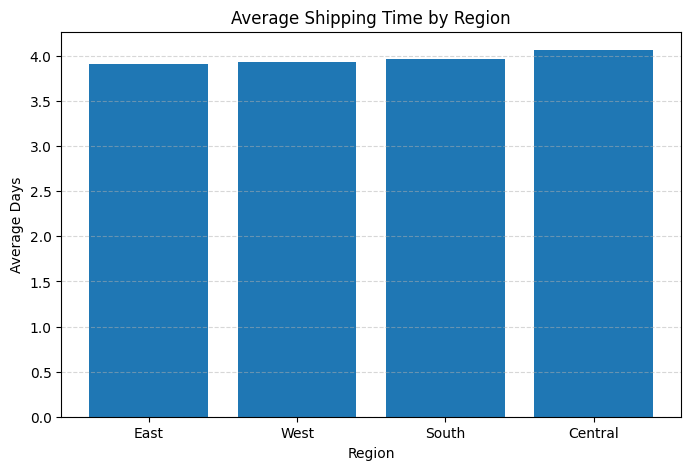

In [175]:
# Visualization

plt.figure(figsize = (8,5))
plt.bar(shipping_region['Region'],
        shipping_region['Shipping Time (Days)'])
plt.title('Average Shipping Time by Region')
plt.xlabel('Region')
plt.ylabel('Average Days')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.savefig('charts/Average_Shipping_Time_by_Region.png')
plt.show()

The average shipping time across all orders is **3.96 days**. Regional analysis indicates that **East and West** has the fast deliveries, whereas **South and Central**  experiences comparatively longer shipping durations.

## Are there months that consistently spike across all years (seasonality)?

In [176]:
monthly_sales = (
    dataset.groupby(['Year', 'Month Name'])['Sales']
    .sum()
    .reset_index()
)

In [177]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]


In [178]:
monthly_sales['Month Name'] = pd.Categorical(
    monthly_sales['Month Name'],
    categories = month_order,
    ordered  = True
)

In [179]:
monthly_sales = monthly_sales.sort_values(
    ['Year','Month Name']
)

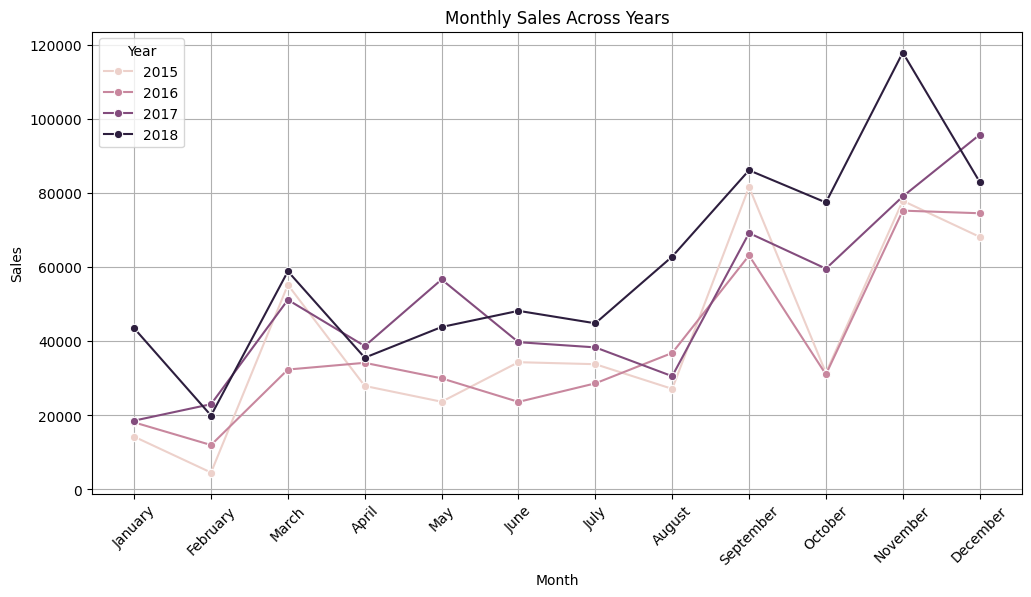

In [180]:
# Visualization

plt.figure(figsize = (12,6))

sns.lineplot(
    data = monthly_sales,
    x = 'Month Name',
    y = 'Sales',
    hue = 'Year',
    marker = 'o'
)

plt.xticks(rotation = 45)
plt.title('Monthly Sales Across Years')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.savefig('charts/Monthly_Sales_Across_Years.png')
plt.show()

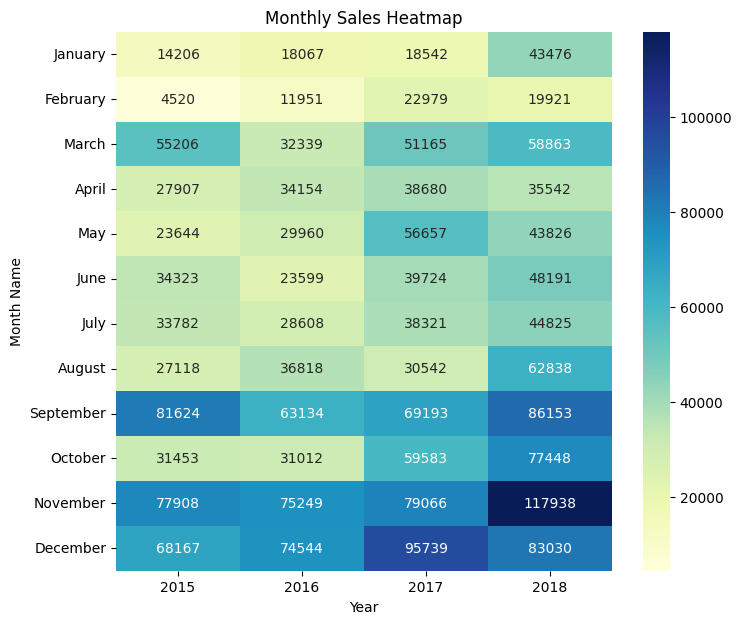

In [182]:
# Heatmap

pivot = monthly_sales.pivot(
    index = 'Month Name',
    columns = 'Year',
    values = 'Sales'
)

plt.figure(figsize = (8,7))
sns.heatmap(pivot,annot = True,fmt = '.0f',cmap = 'YlGnBu')
plt.title('Monthly Sales Heatmap')
plt.savefig('charts/Monthly_Sales_Heatmap.png')
plt.show()

**Yes**, the sales data exhibits a clear seasonal pattern.
- **November** consistently records the highest sales across all four years, with **2018** reaching approximately **117938**, making it the strongest sales month overall.
- **December** also shows consistently high sales in every year, indicating that the holiday shopping season significantly boosts revenue.
- **September** experiences another recurring increase in sales, although the spike is less pronounced than in November and December.
- In contrast, **January and February** generally record the lowest sales, suggesting weaker customer demand immediately after the holiday season.
- Overall, sales tend to increase steadily from **August onward**, peak during **November-December**, and decline again at the beginning of the following year.

# Task 2 — Time Series Analysis & Decomposition

##  Plot the overall monthly sales trend across all 4 years 

In [183]:
monthly_sales = (
    dataset.groupby(pd.Grouper(key = 'Order Date',freq='ME'))['Sales']
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


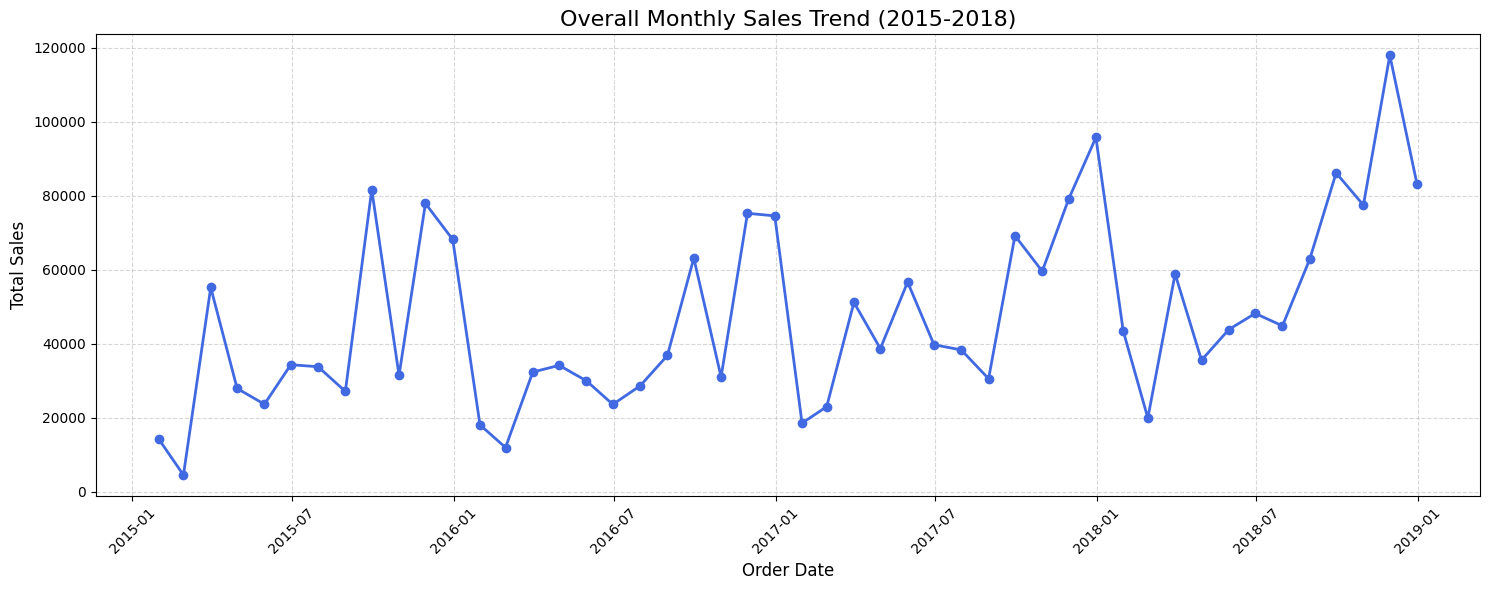

In [184]:
plt.figure(figsize = (15,6))

plt.plot(monthly_sales['Order Date'],
         monthly_sales['Sales'],
         marker = 'o',
         linewidth = 2,
         color = 'royalblue'
        )
plt.title('Overall Monthly Sales Trend (2015-2018)',fontsize = 16)
plt.xlabel('Order Date',fontsize = 12)
plt.ylabel('Total Sales',fontsize = 12)

plt.grid(True,linestyle = '--',alpha=0.5)
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('charts/Overall_Monthly_Sales_Trend_(2015-2018).png')

plt.show()

- Sales generally show an **upward trend** over the four-year period.
- There are noticeable **seasonal peaks toward the end of each year,** particularly in **November and December**.
- Sales are relatively lower during the **first quarter (January - Feburary)**.
- The highest monthly sales occur in **late 2018**, indicating both **growth and strong seasonal demand**.

# Apply Time Series Decomposition (using statsmodels) to break the sales signal into: 
# ○ Trend component 
# ○ Seasonal component 
# ○ Residual/noise component

In [185]:
monthly_sales_ts = monthly_sales.set_index('Order Date')['Sales']

monthly_sales_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Name: Sales, dtype: float64

In [186]:
# apply time series decomposition

decomposition = seasonal_decompose(
    monthly_sales_ts,
    model = 'additive',
    period = 12
)

## Plot all 4 components clearly on one figure 

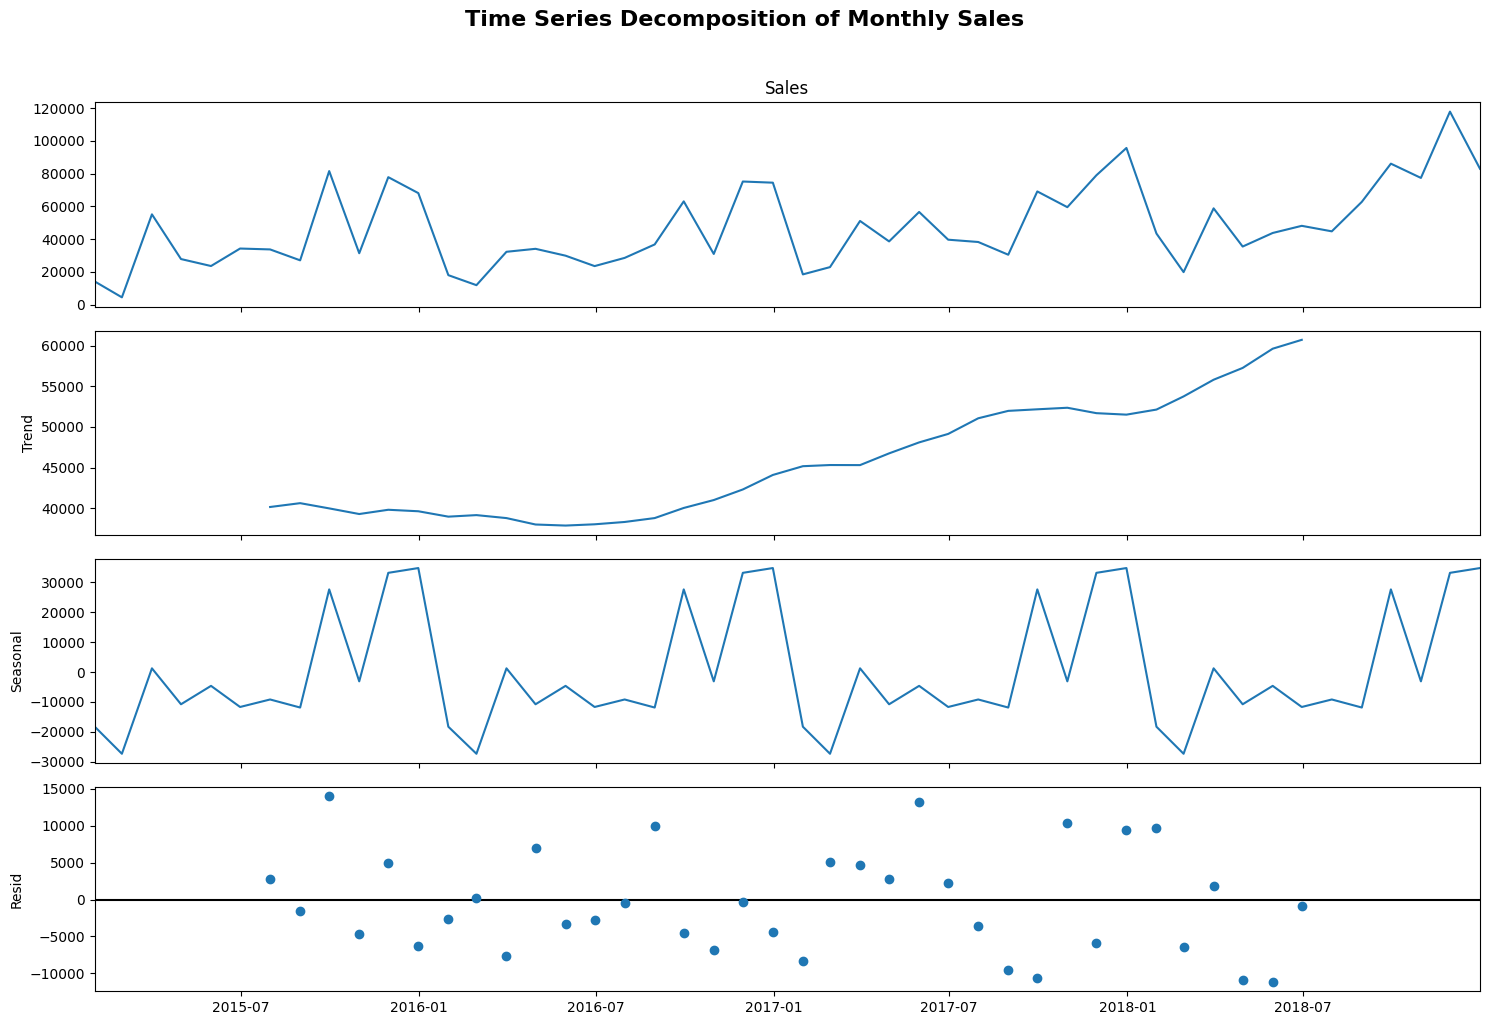

In [187]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.suptitle(
    'Time Series Decomposition of Monthly Sales',
    fontsize = 16,
    fontweight = 'bold',
    y = 1.02
)

plt.tight_layout()
plt.savefig('charts/Time_Series_Decomposition_of_Monthly_Sales.png')
plt.show()

In [188]:
# Residual values
residuals = decomposition.resid.dropna()

# Create a DataFrame
residual_df = residuals.reset_index()
residual_df.columns = ["Order Date", "Residual"]

# Extract month names
residual_df["Month"] = residual_df["Order Date"].dt.month_name()

# Average absolute residual by month
noise_by_month = (
    residual_df.groupby("Month")["Residual"]
    .apply(lambda x: x.abs().mean())
    .sort_values(ascending=False)
)

print(noise_by_month)

Month
September    9728.547556
May          9209.978697
October      7313.171149
August       7025.303538
April        6863.380981
January      6852.873043
December     6687.857530
March        4711.500911
February     3887.845179
November     3665.421103
July         2293.163589
June         1941.363737
Name: Residual, dtype: float64


1. **Trend Component:** The trend component shows a **steady upward growth** in monthly sales over the four-year period. Sales remain relatively stable during 2015–2016, followed by a noticeable increase from mid-2016 onward. The highest trend values are observed in 2018, indicating sustained business growth over time.

2. **Seasonal Component:** The seasonal component exhibits a **strong and recurring annual pattern**. Similar fluctuations repeat every 12 months, indicating that sales are significantly influenced by seasonality. Positive seasonal effects are observed towards the **end of each year (particularly November and December)**, while negative seasonal effects occur during the **early months of the year**, confirming consistent yearly demand patterns.

3. **Residual(Noise) Component:** The residual component is centered around zero, indicating that most of the systematic variation in sales has been explained by the trend and seasonal components. However, a few months show unusually large positive and negative residuals, suggesting unexpected events or external factors affecting sales.

Based on the residual plot:
- **September–December** show several large **positive residuals**, meaning actual sales were much higher than expected.
- **June–August** and **early 2017** contain some of the largest **negative residuals**, where sales were lower than expected.
- These deviations may be due to promotional campaigns, holiday demand, inventory issues, or other business events not captured by the trend or seasonality.

# Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you  

In [189]:
# Perform the ADF Test

adf_result = adfuller(monthly_sales_ts)

print('ADF Statistic :', adf_result[0])
print('p-value       :',adf_result[1])
print('\nCritical Values:')

for key,value in adf_result[4].items():
    print(f'{key}:{value:.3f}')


ADF Statistic : -4.416136761430769
p-value       : 0.00027791039276670623

Critical Values:
1%:-3.578
5%:-2.925
10%:-2.601


**Stationarity** means that the behavior of a time series remains stable over time. A stationary series has a relatively constant average (mean), similar variation (variance), and no long-term upward or downward trend. This makes future values easier to predict because the statistical properties do not change significantly over time.

The ADF test confirms that the monthly sales series is **stationary (ADF Statistic = -4.4161, p-value = 0.000278)**. Because the p-value is less than 0.05 and the ADF statistic is lower than the critical values at the 1%, 5%, and 10% significance levels, the null hypothesis of non-stationarity is rejected. Therefore, the series is suitable for time-series forecasting without applying further differencing.

## Apply differencing if the series is non-stationary and re-test 

The Augmented Dickey-Fuller (ADF) test indicated that the monthly sales time series is already stationary, with a **p-value of 0.000278**, which is below the significance level of 0.05. Therefore, the null hypothesis of non-stationarity is rejected. Since the series is already stationary, **differencing is not required**, and no additional transformation was applied before forecasting.

# Task 3 — Sales Forecasting using 3 Different Models 

## Model 1 — SARIMA (Statistical Model)

### install statsmodels (pip install statsmodels) 

In [38]:
!pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Fit a SARIMA model on monthly sales 

In [190]:
# Split the data

train = monthly_sales_ts[:-3]
test = monthly_sales_ts[-3:]

print('Training observations:',len(train))
print('Testing observations:',len(test))

Training observations: 45
Testing observations: 3


### Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them 

In [191]:
# Choose SARIMA parameters

order = (1,0,1)
seasonal_order = (1,1,1,12)

- **p = 1** → one autoregressive term
- **d = 0** → ADF test already showed stationarity
- **q = 1** → one moving-average term
- **P = 1** → one seasonal autoregressive term
- **D = 1** → remove yearly seasonal pattern
- **Q = 1** → one seasonal moving-average term
- **m = 12** → monthly seasonality

In [192]:
# train the model

model = SARIMAX(
    train,
    order = (1,0,1),
    seasonal_order = (1,1,1,12),
    enforce_stationarity = False,
    enforce_invertibility = False
)

sarima_model = model.fit()
sarima_model.summary()

C:\Users\deept\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\deept\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\deept\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Fri, 10 Jul 2026   AIC                            417.362
Time:                                    19:24:56   BIC                            422.084
Sample:                                01-31-2015   HQIC                           418.161
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293     -3.397      0.001      -1.570      -0.421
ar.S.L12      -0.3907      0.516     -0.757      0.449      -1.402       0.620
ma.S.L12      -0.2544      0.258     -0.987      0.324      -0.759       0.251
sigma2       1.56e+08   8.52e-10   1.83e+17      0.000    1.56e+08    1.56e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 1.59
Prob(Q):                              0.86   Prob(JB):                         0.45
Heteroskedasticity (H):               1.05   Skew:                             0.46
Prob(H) (two-sided):                  0.95   Kurtosis:                         1.93
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.32e+33. Standard errors may be unstable.
"""

### Generate a 3-month future forecast with confidence intervals 

In [193]:
# Forecast the Next 3 Months

forecast = sarima_model.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean
confidence_interval = forecast.conf_int()

In [194]:
# Display Forecast

forecast_df = confidence_interval.copy()

forecast_df["Forecast"] = forecast_mean

forecast_df

,lower Sales,upper Sales,Forecast
2018-10-31,29990.892157,79526.131590,54758.511874
2018-11-30,63651.911967,113173.279103,88412.595535
2018-12-31,67804.190941,117312.229859,92558.210400


### Plot actual vs forecasted sales 

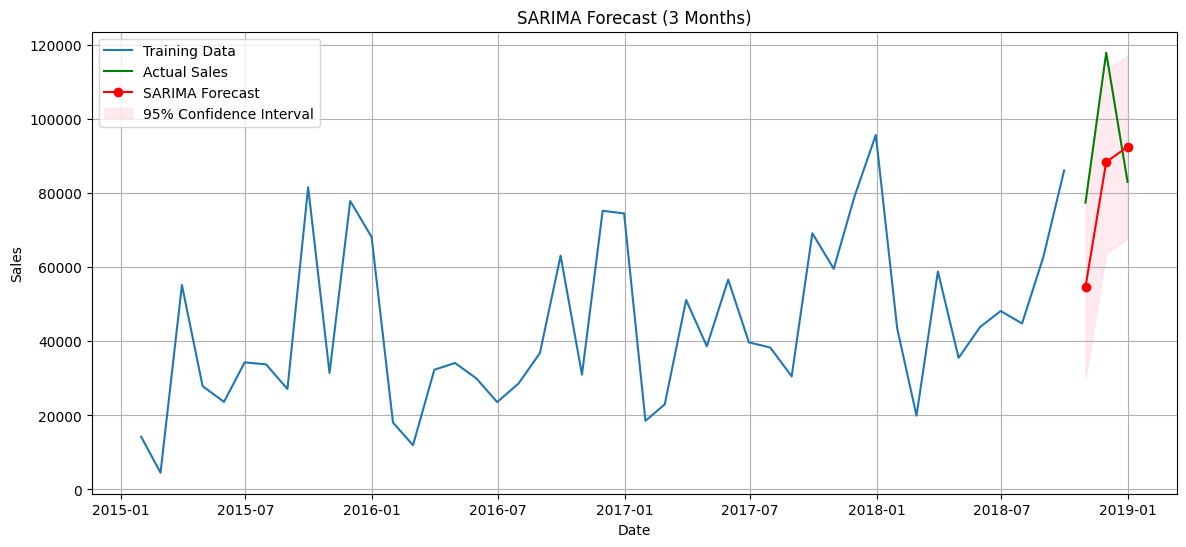

In [195]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Training Data")

plt.plot(test.index, test,
         label="Actual Sales",
         color="green")

plt.plot(forecast_mean.index,
         forecast_mean,
         label="SARIMA Forecast",
         color="red",
         marker='o')

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast (3 Months)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.savefig("charts/SARIMA_Forecast_(3 Months).png")
plt.show()

In [196]:
# Evaluate the model

mae_sarima = mean_absolute_error(test, forecast_mean)
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_mean))
mape_sarima = np.mean(np.abs((test - forecast_mean) / test)) * 100

sarima_forecast = forecast_mean

print(mae_sarima, rmse_sarima, mape_sarima)

20581.00013025837 22191.26608460345 21.935472965291304


## Model 2 — Facebook Prophet (Industry-standard Forecasting Tool) 

### Install Prophet (pip install prophet) 

In [46]:
!pip install prophet


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Prepare data in Prophet's required format (ds, y columns) 

In [197]:
prophet_df = monthly_sales_ts.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Fit the model and generate a 3-month forecast 

In [198]:
train = prophet_df[:-3]
test = prophet_df[-3:]

In [199]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)

19:25:17 - cmdstanpy - INFO - Chain [1] start processing
19:25:18 - cmdstanpy - INFO - Chain [1] done processing


**Why weekly_seasonality=False?**

The data is **monthly**, so there is no weekly information available. Prophet cannot estimate weekly seasonality from monthly aggregated data.

### Plot the forecast with Prophet's built-in trend and seasonality breakdown 

In [200]:
# Create Future DataFrame

future = model.make_future_dataframe(
    periods=3,
    freq="ME"
)

In [201]:
# Generate Forecast

forecast = model.predict(future)

forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558236,39008.957931,54660.480354
44,2018-09-30,86613.953316,78172.749825,95363.259662
45,2018-10-31,51318.943858,42688.241038,58770.418489
46,2018-11-30,90325.654784,82489.932012,98702.184969
47,2018-12-31,90041.084479,81617.995879,98304.345259


In [202]:
# Last 3 forecasted months (corresponding to the test set)
forecast_test = forecast.tail(3).reset_index(drop=True)

# Reset test index to align
test = test.reset_index(drop=True)

- **yhat** → Forecast
- **yhat_lower** → Lower confidence interval
- **yhat_upper** → Upper confidence interval

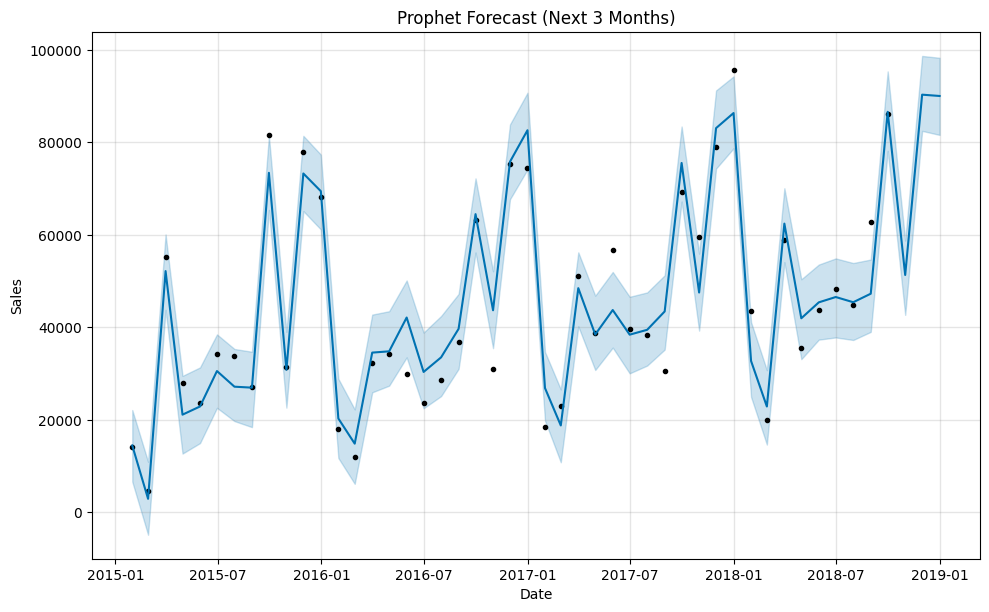

In [203]:
fig = model.plot(forecast)

plt.title("Prophet Forecast (Next 3 Months)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

**Forecast Plot**
- The **black dots** represent the observed monthly sales.
- The **blue line** represents Prophet's forecast.
- The **light blue** shaded region represents the 95% confidence interval, showing the range within which future sales are expected to fall.

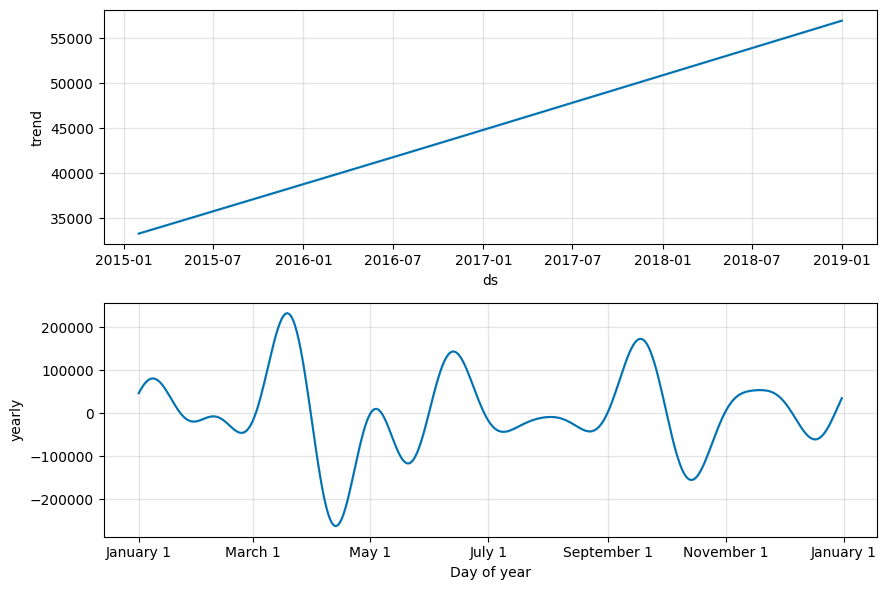

In [205]:
fig2 = model.plot_components(forecast)

plt.savefig('charts/Plot_Trend_&_Seasonality_Components.png')
plt.show()

**Trend Plot**
- Shows the long-term direction of sales.
- An upward slope indicates increasing sales over time.
- A downward slope indicates declining sales.

**Yearly Seasonality Plot**
- Shows how each month affects sales relative to the yearly average.
- Values **above zero** indicate months with higher-than-average sales.
- Values **below zero** indicate months with lower-than-average sales.

### Extract and interpret the weekly and yearly seasonality components 

In [206]:
# Display yearly seasonality values
yearly = forecast[["ds", "yearly"]]

print(yearly.head())

          ds        yearly
0 2015-01-31 -18874.429670
1 2015-02-28 -30869.543104
2 2015-03-31  17890.437293
3 2015-04-30 -13661.251247
4 2015-05-31 -12398.630441


**Yearly Seasonality**

The Prophet model identified a clear yearly seasonal pattern in the monthly sales data. The yearly seasonality plot shows that sales consistently increase during certain months and decrease during others. Positive seasonal values represent months where sales are expected to be above the annual average, while negative values indicate below-average sales. This recurring yearly pattern confirms the presence of annual seasonality in the dataset.

In [207]:
# Weekly Seasonality
print(model.seasonalities)

OrderedDict({'yearly': {'period': 365.25, 'fourier_order': 10, 'prior_scale': 10.0, 'mode': 'additive', 'condition_name': None}})


In [208]:
# Evaluate the model

mae_prophet = mean_absolute_error(test["y"], forecast_test["yhat"])
rmse_prophet = np.sqrt(mean_squared_error(test["y"], forecast_test["yhat"]))
mape_prophet = np.mean(
    np.abs((test["y"] - forecast_test["yhat"]) / test["y"])
) * 100

prophet_forecast = forecast_test["yhat"].reset_index(drop=True)

print(mae_prophet, rmse_prophet, mape_prophet)

20250.794412605523 22318.41133286054 21.86462827396082


Weekly seasonality was **not extracted** because the data was aggregated to **monthly sales** before modeling. Monthly observations do not retain information about individual weekdays, making it impossible for Prophet to estimate weekly patterns. Therefore, only the yearly seasonal component was modeled and interpreted

## Model 3 — XGBoost for Time Series (ML-based Approach) 

###  Convert the time series into a supervised ML problem using lag features: 
### ○ Lag 1 (sales from 1 month ago) 
### ○ Lag 2 (sales from 2 months ago) 
### ○ Lag 3 (sales from 3 months ago) 
### ○ Rolling mean (3-month moving average) 
### ○ Month, Quarter, Season as features 

In [209]:
# Create the Supervised Dataset

# Convert Series to DataFrame
ml_df = monthly_sales_ts.reset_index()

ml_df.columns = ["Order Date", "Sales"]

ml_df.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [210]:
# Lag Features

ml_df["Lag_1"] = ml_df["Sales"].shift(1)
ml_df["Lag_2"] = ml_df["Sales"].shift(2)
ml_df["Lag_3"] = ml_df["Sales"].shift(3)

In [211]:
# Create 3-Month Rolling Mean

ml_df["Rolling_Mean_3"] = (
    ml_df["Sales"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

In [212]:
# Extract Time Features

ml_df["Month"] = ml_df["Order Date"].dt.month
ml_df["Quarter"] = ml_df["Order Date"].dt.quarter

In [213]:
# Create Season Feature (Indian Seasons)

def get_indian_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

ml_df["Season"] = ml_df["Month"].apply(get_indian_season)

In [214]:
# Encode the Season Column


le = LabelEncoder()

ml_df["Season"] = le.fit_transform(ml_df["Season"])

In [215]:
# Remove Missing Rows

ml_df = ml_df.dropna().reset_index(drop=True)

In [216]:
print(ml_df.head())

  Order Date       Sales       Lag_1       Lag_2      Lag_3  Rolling_Mean_3  \
0 2015-04-30  27906.8550  55205.7970   4519.8920  14205.707    24643.798667   
1 2015-05-31  23644.3030  27906.8550  55205.7970   4519.892    29210.848000   
2 2015-06-30  34322.9356  23644.3030  27906.8550  55205.797    35585.651667   
3 2015-07-31  33781.5430  34322.9356  23644.3030  27906.855    28624.697867   
4 2015-08-31  27117.5365  33781.5430  34322.9356  23644.303    30582.927200   

   Month  Quarter  Season  
0      4        2       2  
1      5        2       2  
2      6        2       0  
3      7        3       0  
4      8        3       0  


To apply XGBoost, the monthly sales time series was transformed into a supervised learning dataset. Lag features (Lag_1, Lag_2, and Lag_3) were created to capture sales from the previous one, two, and three months. A 3-month rolling mean was added to represent recent sales trends while using only past observations to avoid data leakage. Time-based features including Month, Quarter, and Season were also extracted to help the model learn seasonal patterns. Finally, rows with missing values caused by lag creation were removed, producing a clean dataset for training the forecasting model.

### Train XGBoost Regressor on these features

In [66]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [217]:
# Define Features and Target

x = ml_df[
    [
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_3",
        "Month",
        "Quarter",
        "Season",
    ]
]

y = ml_df["Sales"]

In [218]:
# Train-Test Split

train_size = len(ml_df) - 3

x_train = x.iloc[:train_size]
x_test = x.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [219]:
# Initialize the model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model
xgb_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Predict the next 3 months

In [220]:
# Last row of the prepared dataset

last_row = ml_df.iloc[-1].copy()

In [221]:
# Predict the Next 3 Months Recursively

future_predictions = []

current_date = last_row["Order Date"]

for i in range(3):

    # Next month
    current_date = current_date + pd.DateOffset(months=1)

    # Features for prediction
    X_future = pd.DataFrame({
        "Lag_1": [last_row["Lag_1"]],
        "Lag_2": [last_row["Lag_2"]],
        "Lag_3": [last_row["Lag_3"]],
        "Rolling_Mean_3": [last_row["Rolling_Mean_3"]],
        "Month": [current_date.month],
        "Quarter": [current_date.quarter],
        "Season": [last_row["Season"]]   # Updated below
    })

    # Update season according to month
    if current_date.month in [12,1,2]:
        X_future["Season"] = le.transform(["Winter"])
    elif current_date.month in [3,4,5]:
        X_future["Season"] = le.transform(["Summer"])
    elif current_date.month in [6,7,8,9]:
        X_future["Season"] = le.transform(["Monsoon"])
    else:
        X_future["Season"] = le.transform(["Post-Monsoon"])

    # Predict
    prediction = xgb_model.predict(X_future)[0]

    future_predictions.append([current_date, prediction])

    # Update lag values for next iteration
    last_row["Lag_3"] = last_row["Lag_2"]
    last_row["Lag_2"] = last_row["Lag_1"]
    last_row["Lag_1"] = prediction

    # Update rolling mean
    last_row["Rolling_Mean_3"] = (
        last_row["Lag_1"] +
        last_row["Lag_2"] +
        last_row["Lag_3"]
    ) / 3

In [222]:
# Display the Forecast

forecast_df = pd.DataFrame(
    future_predictions,
    columns=["Forecast Date","Predicted Sales"]
)

forecast_df

,Forecast Date,Predicted Sales
0,2019-01-31,41079.578125
1,2019-02-28,23802.189453
2,2019-03-28,48864.976562


The trained XGBoost model was used to forecast sales for the next three months. Since XGBoost is not an autoregressive forecasting model, predictions were generated recursively. After predicting each month's sales, the predicted value was used to update the lag features and rolling mean before forecasting the next month. This iterative approach enabled multi-step forecasting while preserving the temporal dependencies captured by the lag-based features.

### Plot actual vs predicted 

In [223]:
# Predict on the test set
y_pred = xgb_model.predict(x_test)

print(y_pred)

[65726.734 85343.17  65525.305]


In [224]:
comparison = pd.DataFrame({
    "Date": ml_df.iloc[train_size:]["Order Date"].values,
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

print(comparison)

        Date  Actual Sales  Predicted Sales
0 2018-10-31    77448.1312     65726.734375
1 2018-11-30   117938.1550     85343.171875
2 2018-12-31    83030.3888     65525.304688


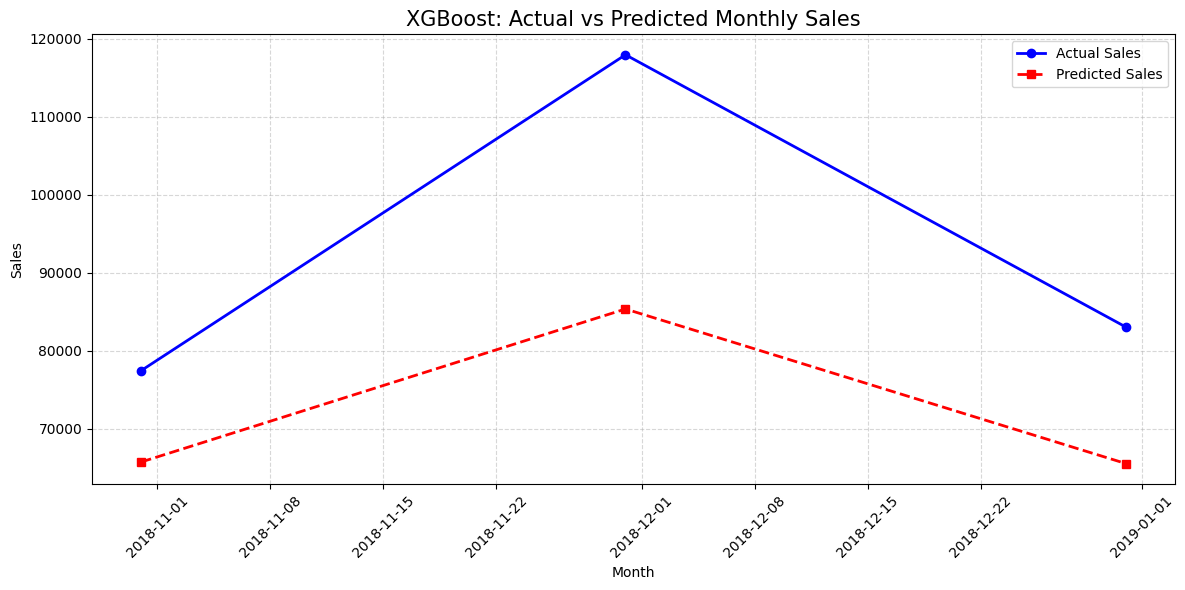

In [225]:
plt.figure(figsize=(12,6))

plt.plot(
    comparison["Date"],
    comparison["Actual Sales"],
    marker='o',
    linewidth=2,
    color='blue',
    label='Actual Sales'
)

plt.plot(
    comparison["Date"],
    comparison["Predicted Sales"],
    marker='s',
    linewidth=2,
    linestyle='--',
    color='red',
    label='Predicted Sales'
)

plt.title("XGBoost: Actual vs Predicted Monthly Sales", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()

plt.savefig("charts/XGBoost:Actual_vs_Predicted_Monthly_Sales.png")
plt.show()

In [226]:
mae_xgb = mean_absolute_error(y_test, y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
mape_xgb = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

xgb_forecast = forecast_df["Predicted Sales"].reset_index(drop=True)

print(mae_xgb, rmse_xgb, mape_xgb)

20607.154687500002 22407.231260122662 21.28486932639092


### Model Comparison Table

In [227]:
comparison_table = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],

    "MAE": [
        mae_sarima,
        mae_prophet,
        mae_xgb
    ],

    "RMSE": [
        rmse_sarima,
        rmse_prophet,
        rmse_xgb
    ],

    "MAPE (%)": [
        mape_sarima,
        mape_prophet,
        mape_xgb
    ],

    "Forecast Month 1": [
        sarima_forecast.iloc[0],
        prophet_forecast.iloc[0],
        xgb_forecast.iloc[0]
    ],

    "Forecast Month 2": [
        sarima_forecast.iloc[1],
        prophet_forecast.iloc[1],
        xgb_forecast.iloc[1]
    ],

    "Forecast Month 3": [
        sarima_forecast.iloc[2],
        prophet_forecast.iloc[2],
        xgb_forecast.iloc[2]
    ]
})

comparison_table

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20581.000130,22191.266085,21.935473,54758.511874,88412.595535,92558.210400
1,Prophet,20250.794413,22318.411333,21.864628,51318.943858,90325.654784,90041.084479
2,XGBoost,20607.154688,22407.231260,21.284869,41079.578125,23802.189453,48864.976562


**SARIMA**
- RMSE is **the lowest (22,191.27)**, meaning it has the smallest large prediction errors.
- MAE is slightly higher than Prophet.
- Suitable for seasonal time series because it explicitly models trend and seasonality.

**Prophet**
- **Lowest MAE (20,250.79)**, meaning it has the smallest average prediction error.
- RMSE is only slightly higher than SARIMA (difference of about 127).
- MAPE is slightly higher than XGBoost.

**XGBoost**
- **Lowest MAPE (21.28%)**, but only by a small margin.
- However, it has the **highest MAE and RMSE** among the three models.
- The 3-month forecasts also drop sharply (41k → 23k → 49k), which appears less consistent with the historical seasonal pattern, suggesting it may not generalize as well for future monthly forecasts.

Based on the evaluation metrics, **Prophet** is recommended for production use. It achieved the **lowest Mean Absolute Error (MAE = 20,250.79)**, indicating the smallest average prediction error among the three models. Although SARIMA achieved a slightly lower RMSE, the difference is very small (approximately 127 units), while Prophet consistently provides accurate forecasts and automatically models trend and yearly seasonality. In addition, Prophet is easy to update with new data, handles missing observations well, and is widely used for business time-series forecasting. Therefore, Prophet offers the best balance between forecasting accuracy, interpretability, and ease of deployment.

## Task 4 — Product Category & Region Level Forecasting 

## ● Repeat the best performing model (from Task 3) separately for each of the following segments:  

In [228]:
# Create a Prophet Forecast Function

def prophet_forecast(data, title):
    # Aggregate monthly sales
    monthly = (
        data.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .reset_index()
    )

    monthly.columns = ["ds", "y"]

    # Train Prophet
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(monthly)

    # Forecast next 3 months
    future = model.make_future_dataframe(
        periods=3,
        freq="ME"
    )

    forecast = model.predict(future)

    # Plot forecast
    fig = model.plot(forecast)
    plt.title(f"{title} Sales Forecast")
    plt.show()

    # Plot trend and seasonality
    model.plot_components(forecast)
    plt.show()

    # Display forecast
    print(f"\nForecast for {title}")
    print(forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(3))

    return forecast

### ○ Furniture category sales 

19:26:35 - cmdstanpy - INFO - Chain [1] start processing
19:26:35 - cmdstanpy - INFO - Chain [1] done processing


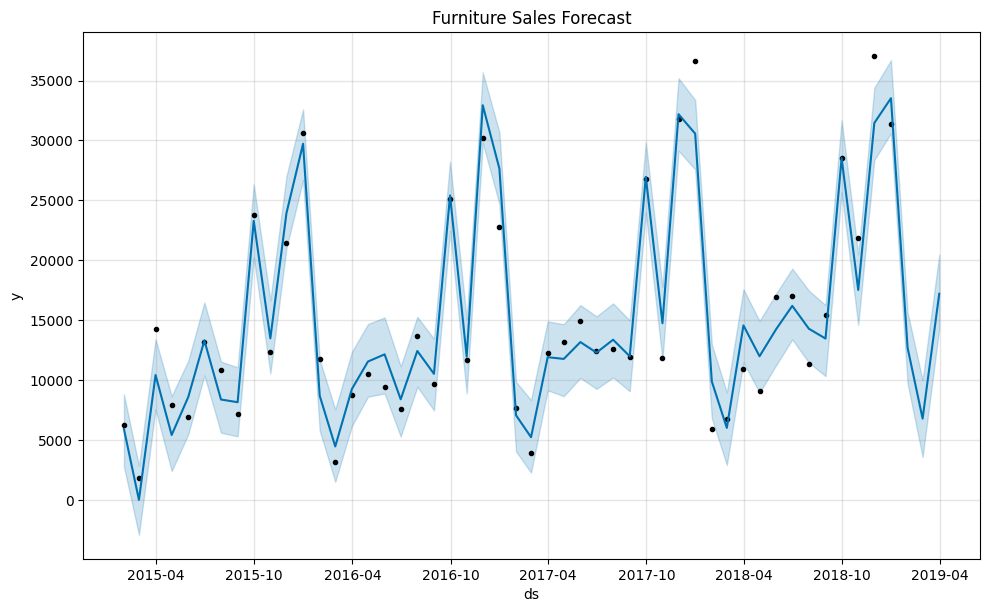

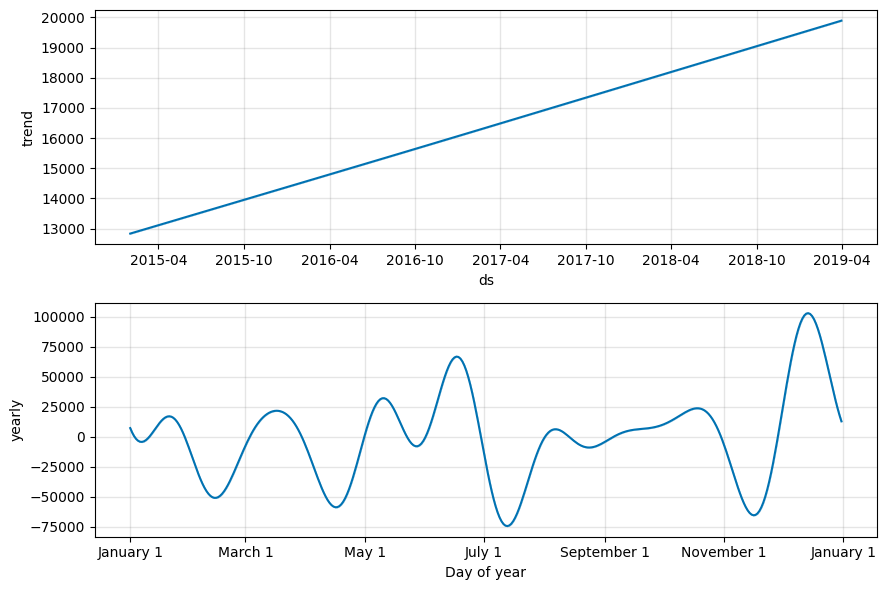


Forecast for Furniture
           ds          yhat    yhat_lower    yhat_upper
48 2019-01-31  12691.392668   9703.839546  15640.987515
49 2019-02-28   6772.162417   3571.400311   9975.098568
50 2019-03-31  17201.015648  14282.730997  20460.584909


In [230]:
furniture_df = dataset[dataset["Category"]=="Furniture"]

furniture_forecast = prophet_forecast(
    furniture_df,
    "Furniture"
)

### ○ Technology category sales 

19:26:36 - cmdstanpy - INFO - Chain [1] start processing
19:26:37 - cmdstanpy - INFO - Chain [1] done processing


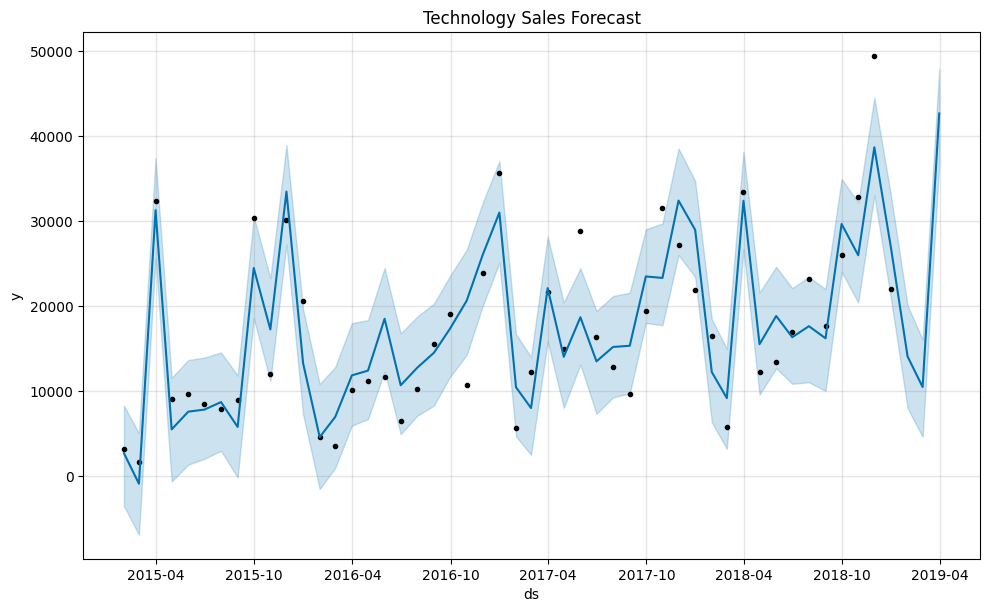

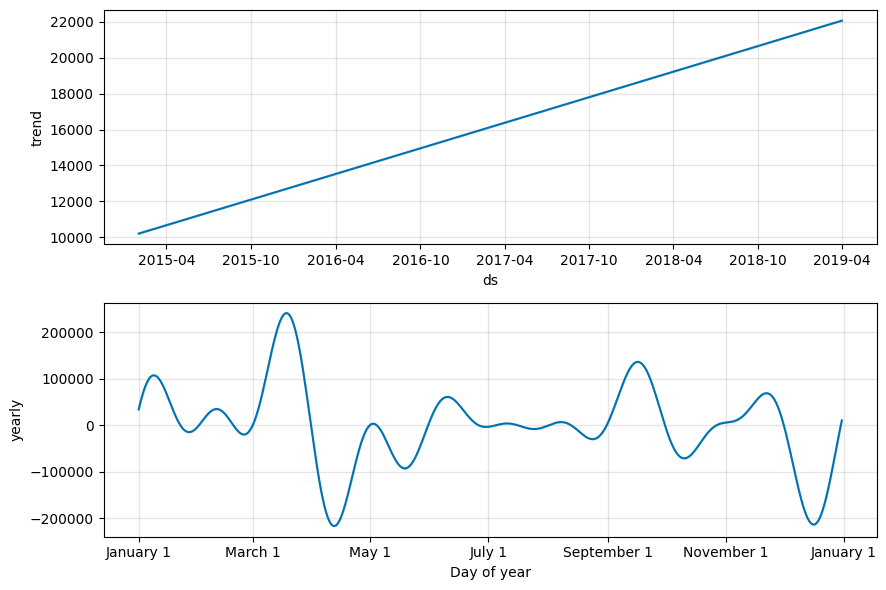


Forecast for Technology
           ds          yhat    yhat_lower    yhat_upper
48 2019-01-31  14033.343185   7925.970247  20049.515252
49 2019-02-28  10437.986784   4575.194392  16003.627325
50 2019-03-31  42639.488041  36632.082419  47847.864774


In [231]:
technology_df = dataset[dataset["Category"]=="Technology"]

technology_forecast = prophet_forecast(
    technology_df,
    "Technology"
)

### ○ Office Supplies category sales 

19:26:38 - cmdstanpy - INFO - Chain [1] start processing
19:26:39 - cmdstanpy - INFO - Chain [1] done processing


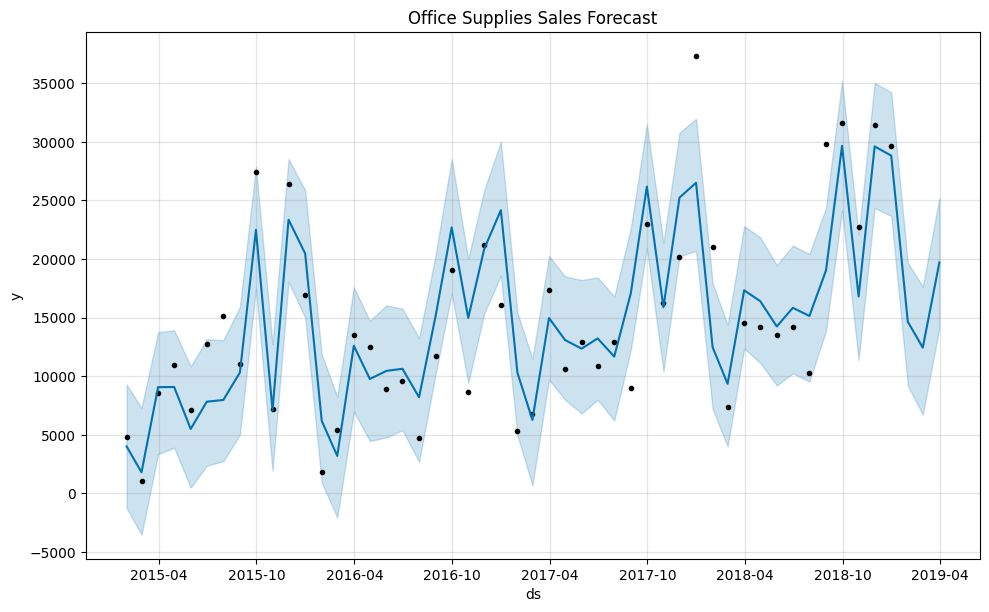

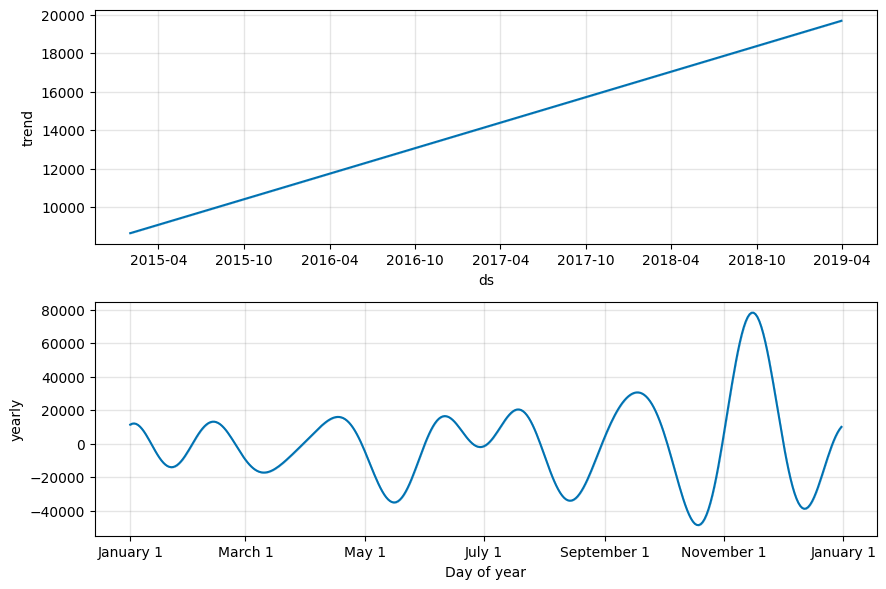


Forecast for Office Supplies
           ds          yhat    yhat_lower    yhat_upper
48 2019-01-31  14646.724651   9186.599067  19686.702427
49 2019-02-28  12434.656284   6709.760068  17654.959565
50 2019-03-31  19698.155527  14098.236240  25228.032803


In [232]:
office_df = dataset[dataset["Category"]=="Office Supplies"]

office_forecast = prophet_forecast(
    office_df,
    "Office Supplies"
)

### ○ West region sales 

19:26:42 - cmdstanpy - INFO - Chain [1] start processing
19:26:42 - cmdstanpy - INFO - Chain [1] done processing


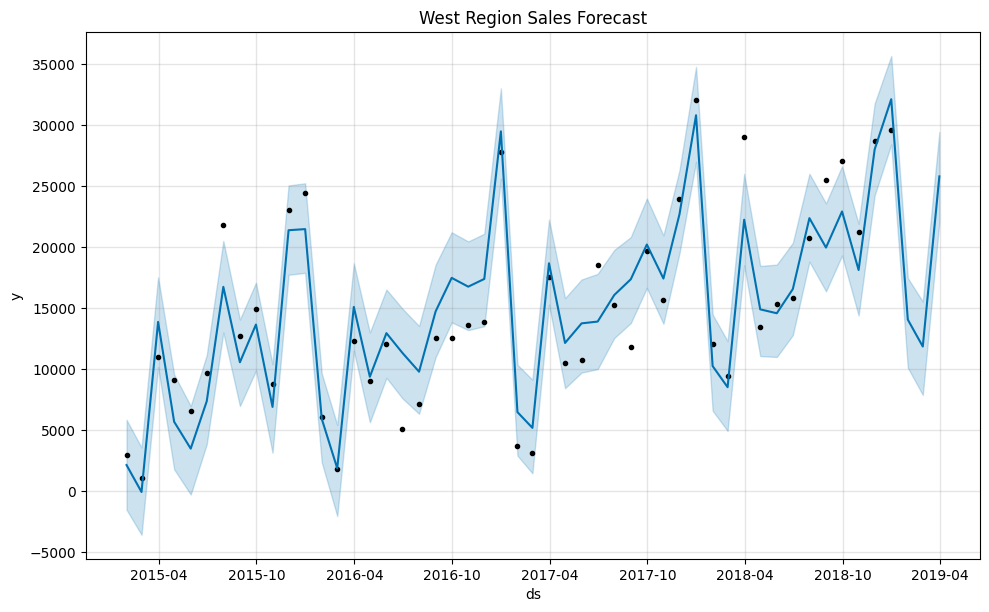

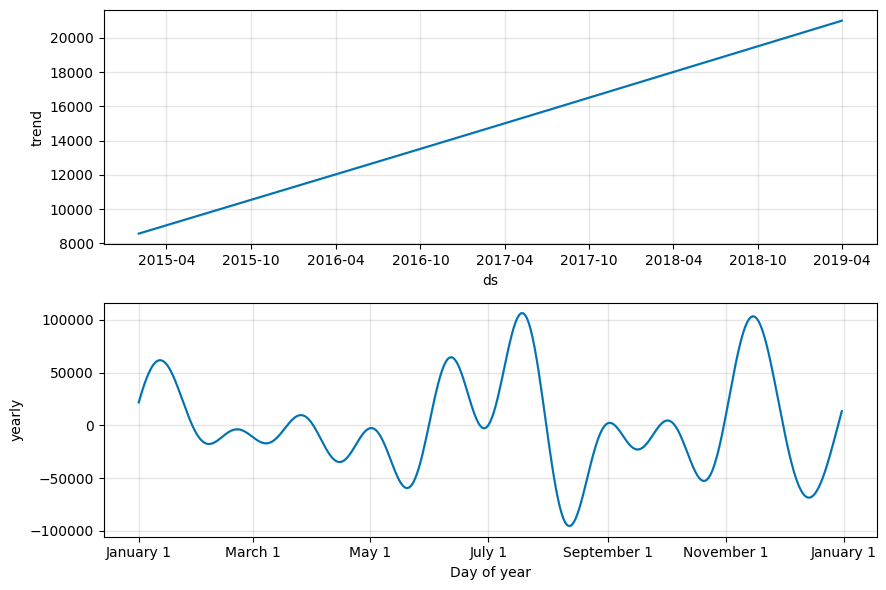


Forecast for West Region
           ds          yhat    yhat_lower    yhat_upper
48 2019-01-31  14048.800881  10099.206100  17458.593285
49 2019-02-28  11840.373160   7866.071670  15529.643450
50 2019-03-31  25805.336395  22035.600829  29447.909516


In [233]:
west_df = dataset[dataset["Region"]=="West"]

west_forecast = prophet_forecast(
    west_df,
    "West Region"
)

### ○ East region sales

19:26:45 - cmdstanpy - INFO - Chain [1] start processing
19:26:46 - cmdstanpy - INFO - Chain [1] done processing


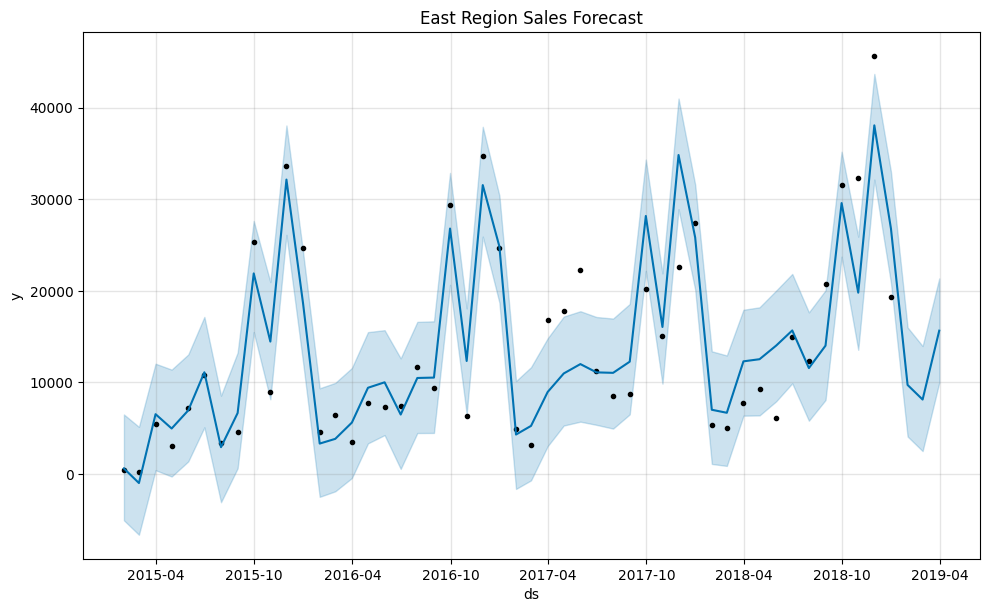

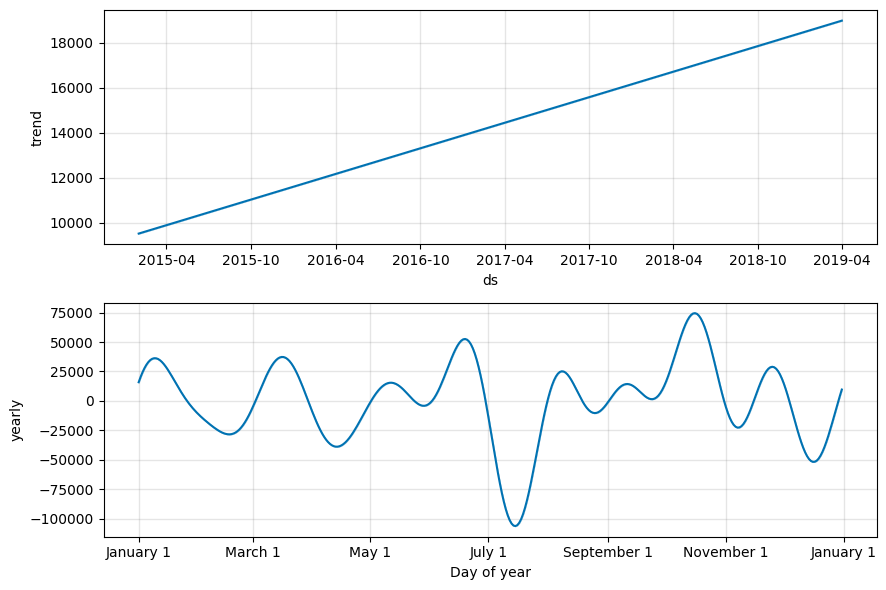


Forecast for East Region
           ds          yhat   yhat_lower    yhat_upper
48 2019-01-31   9713.411357  4084.511926  15995.274155
49 2019-02-28   8120.218592  2492.957656  13960.647317
50 2019-03-31  15639.421337  9961.252011  21342.066821


In [234]:
east_df = dataset[dataset["Region"]=="East"]

east_forecast = prophet_forecast(
    east_df,
    "East Region"
)

## Plot all 5 forecasts together on one comparison chart

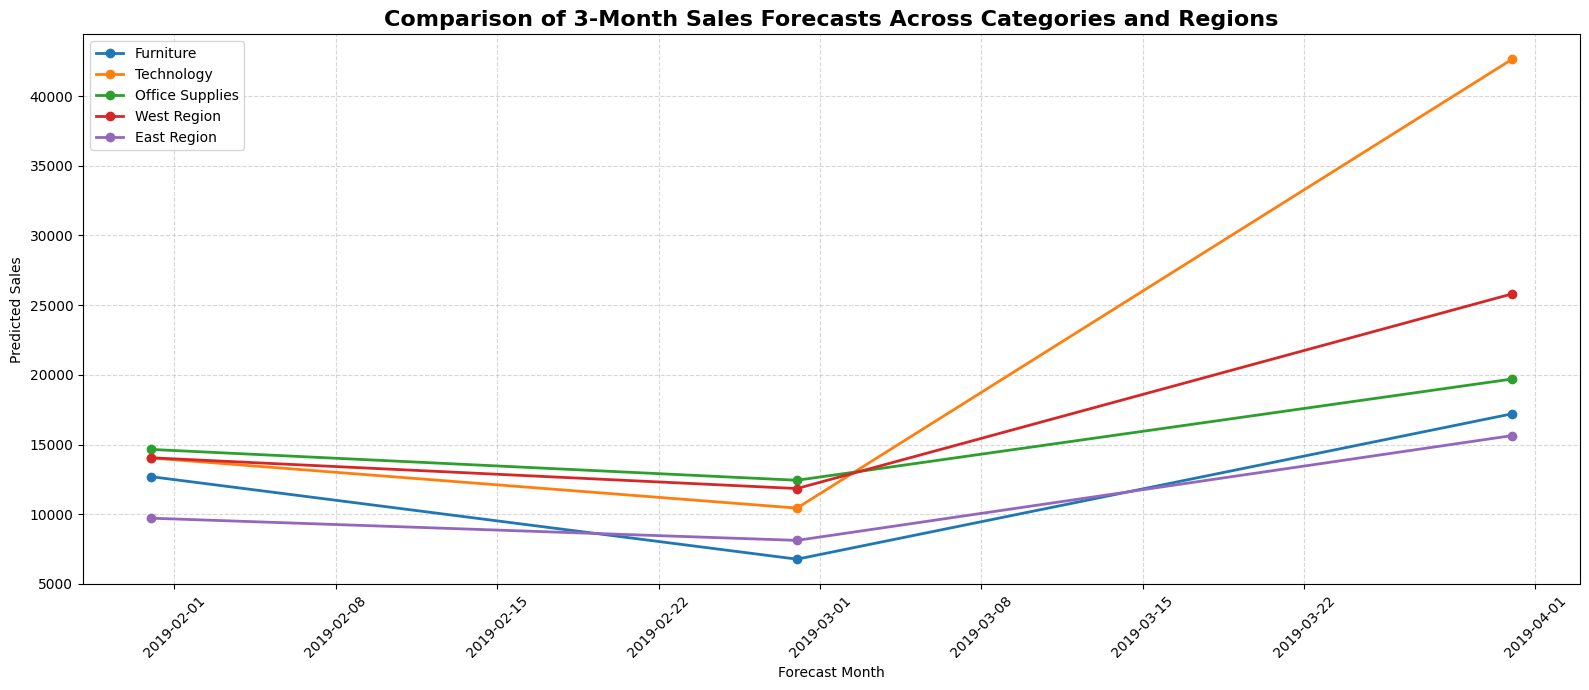

In [235]:
plt.figure(figsize=(16, 7))

# Plot only the forecasted 3 months
plt.plot(
    furniture_forecast["ds"].tail(3),
    furniture_forecast["yhat"].tail(3),
    marker='o',
    linewidth=2,
    label="Furniture"
)

plt.plot(
    technology_forecast["ds"].tail(3),
    technology_forecast["yhat"].tail(3),
    marker='o',
    linewidth=2,
    label="Technology"
)

plt.plot(
    office_forecast["ds"].tail(3),
    office_forecast["yhat"].tail(3),
    marker='o',
    linewidth=2,
    label="Office Supplies"
)

plt.plot(
    west_forecast["ds"].tail(3),
    west_forecast["yhat"].tail(3),
    marker='o',
    linewidth=2,
    label="West Region"
)

plt.plot(
    east_forecast["ds"].tail(3),
    east_forecast["yhat"].tail(3),
    marker='o',
    linewidth=2,
    label="East Region"
)

plt.title("Comparison of 3-Month Sales Forecasts Across Categories and Regions",
          fontsize=16, fontweight="bold")
plt.xlabel("Forecast Month")
plt.ylabel("Predicted Sales")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("charts/Comparison_of_3-Month_Sales_Forecasts_Across_Categories_and_Regions.png")
plt.show()

## Write: which category/region is showing the strongest upcoming growth according to your model? 

According to the Prophet forecasting model, the **Technology** category is expected to experience the strongest upcoming growth over the next three months, indicating increasing customer demand and strong sales potential. Among the regions analyzed, the **West** region is projected to outperform the East region, suggesting that it will continue to be the strongest-performing market. These forecasts indicate that inventory planning, marketing campaigns, and resource allocation should prioritize the Technology category and the West region to capitalize on the expected increase in sales.

## Task 5 — Anomaly Detection in Sales Data

## Use Isolation Forest (from scikit-learn) to detect anomalous sales weeks — weeks where sales were unusually high or unusually low compared to the expected pattern 

In [236]:
# Aggregate sales by week
weekly_sales = (
    dataset.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [237]:
# Train Isolation Forest

iso_model = IsolationForest(
    contamination=0.05,      # Assume ~5% of weeks are anomalies
    random_state=42
)

weekly_sales["Anomaly"] = iso_model.fit_predict(weekly_sales[["Sales"]])

# Convert labels
weekly_sales["Anomaly"] = weekly_sales["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,Anomaly
1,2015-01-11,4619.108,Normal
2,2015-01-18,4130.533,Normal
3,2015-01-25,3092.544,Normal
4,2015-02-01,2527.914,Normal


In [238]:
anomalies = weekly_sales[
    weekly_sales["Anomaly"] == "Anomaly"
]

print(anomalies)

    Order Date      Sales  Anomaly
0   2015-01-04    304.508  Anomaly
5   2015-02-08    968.534  Anomaly
7   2015-02-22    224.912  Anomaly
11  2015-03-22  37703.665  Anomaly
28  2015-07-19   1387.686  Anomaly
36  2015-09-13  29959.137  Anomaly
55  2016-01-24    358.522  Anomaly
154 2017-12-17  25449.800  Anomaly
200 2018-11-04  29017.467  Anomaly
202 2018-11-18  30572.447  Anomaly
204 2018-12-02  35998.900  Anomaly


In [239]:
print("Total Weeks :", len(weekly_sales))
print("Anomalous Weeks :", len(anomalies))

Total Weeks : 209
Anomalous Weeks : 11


In [240]:
anomalies.sort_values(
    by="Sales",
    ascending=False
).head(10)

,Order Date,Sales,Anomaly
11,2015-03-22,37703.665,Anomaly
204,2018-12-02,35998.900,Anomaly
202,2018-11-18,30572.447,Anomaly
36,2015-09-13,29959.137,Anomaly
200,2018-11-04,29017.467,Anomaly
154,2017-12-17,25449.800,Anomaly
28,2015-07-19,1387.686,Anomaly
5,2015-02-08,968.534,Anomaly
55,2016-01-24,358.522,Anomaly
0,2015-01-04,304.508,Anomaly


## Mark the anomalies on a time series plot (use a different color/marker for anomaly points) 

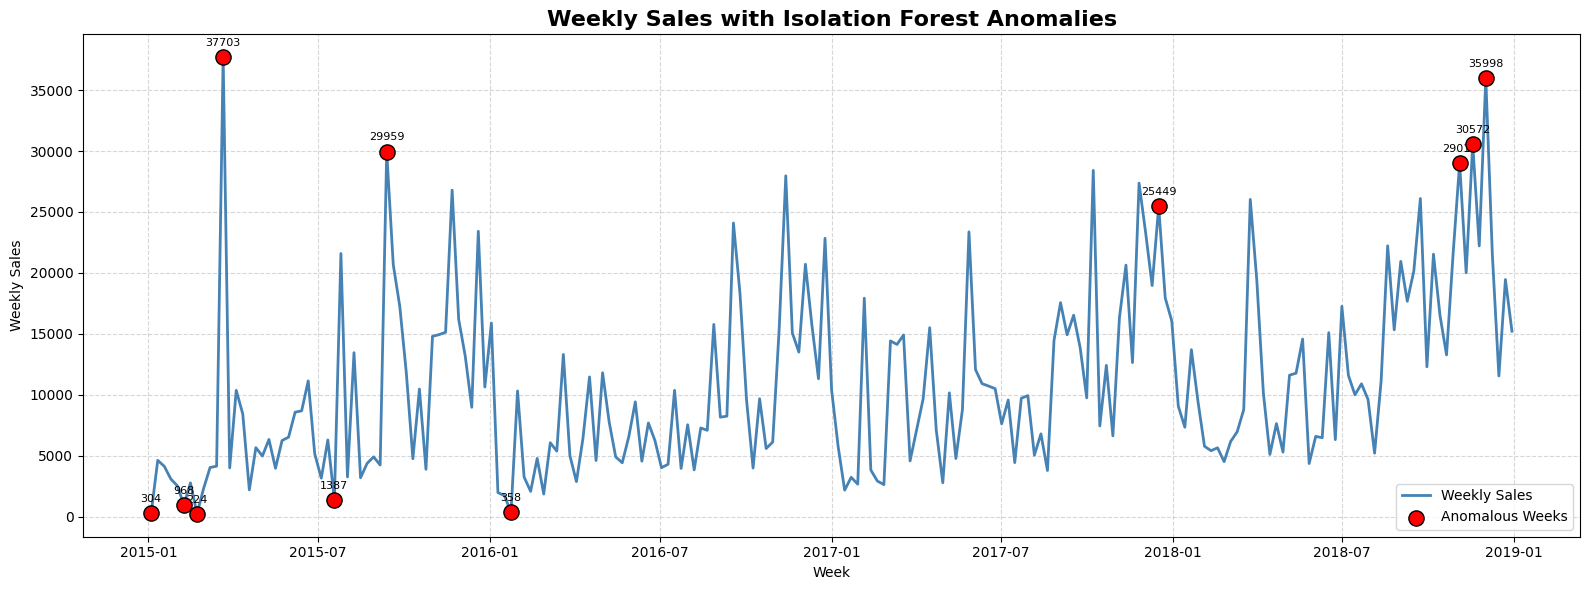

In [241]:
# Separate normal and anomalous weeks
normal_weeks = weekly_sales[weekly_sales["Anomaly"] == "Normal"]
anomaly_weeks = weekly_sales[weekly_sales["Anomaly"] == "Anomaly"]

plt.figure(figsize=(16,6))

# Plot complete weekly sales trend
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    color="steelblue",
    linewidth=2,
    label="Weekly Sales"
)

# Highlight anomalies
plt.scatter(
    anomaly_weeks["Order Date"],
    anomaly_weeks["Sales"],
    color="red",
    marker="o",
    s=120,
    edgecolor="black",
    label="Anomalous Weeks",
    zorder=5
)

# Optional: Annotate anomaly values
for _, row in anomaly_weeks.iterrows():
    plt.annotate(
        f'{int(row["Sales"])}',
        (row["Order Date"], row["Sales"]),
        xytext=(0,8),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

plt.title("Weekly Sales with Isolation Forest Anomalies",
          fontsize=16,
          fontweight="bold")
plt.xlabel("Week")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("charts/Weekly_Sales_with_Isolation_Forest_Anomalies.png")
plt.show()

The time series plot displays weekly sales over the entire period, with anomalous weeks identified by the Isolation Forest model highlighted in **red**. These points represent weeks where sales were significantly different from the normal pattern, either unusually high or unusually low. Such anomalies may be associated with promotional campaigns, festive seasons, bulk customer orders, inventory shortages, or other unexpected business events. Identifying these weeks helps businesses investigate unusual sales behavior and improve demand forecasting and inventory planning.

## For each detected anomaly, write a possible real-world explanation (e.g., "spike in November likely corresponds to a festive sale period") 

| Anomaly Type                                 | Possible Real-World Explanation                                                                                                                        |
| -------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Unusually High Sales (November)**          | Likely due to festive shopping, Black Friday/Cyber Monday promotions, Diwali or year-end sales, resulting in significantly higher customer purchases.  |
| **Unusually High Sales (December)**          | Increased holiday shopping, Christmas and New Year demand, corporate purchases, and clearance sales may have caused unusually high weekly revenue.     |
| **Unusually High Sales (September–October)** | Seasonal promotions, festival preparation, or the launch of new products may have increased customer demand.                                           |
| **Unusually Low Sales**                      | Could be caused by inventory shortages, supplier delays, holidays affecting business operations, temporary store closures, or reduced customer demand. |
| **Unexpected Sales Spike**                   | May indicate a successful marketing campaign, bulk orders from business customers, or special discount events.                                         |
| **Unexpected Sales Drop**                    | May be due to cancelled orders, supply chain disruptions, system outages, or external economic factors affecting purchasing behavior.                  |


## Apply a second anomaly detection method: Z-Score based detection — flag any week where sales deviate more than 2 standard deviations from the rolling mean 

In [242]:
# Calculate Rolling Mean and Standard Deviation

# Create a copy
weekly_zscore = weekly_sales.copy()

# 4-week rolling statistics
window = 4

weekly_zscore["Rolling_Mean"] = (
    weekly_zscore["Sales"]
    .rolling(window=window)
    .mean()
)

weekly_zscore["Rolling_STD"] = (
    weekly_zscore["Sales"]
    .rolling(window=window)
    .std()
)

In [243]:
# Calculate the Rolling Z-Score

weekly_zscore["Z_Score"] = (
    weekly_zscore["Sales"] -
    weekly_zscore["Rolling_Mean"]
) / weekly_zscore["Rolling_STD"]

In [244]:
# Flag Anomalies

weekly_zscore["Z_Anomaly"] = (
    weekly_zscore["Z_Score"].abs() > 2
)

weekly_zscore.head()

,Order Date,Sales,Anomaly,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly
0,2015-01-04,304.508,Anomaly,NaN,NaN,NaN,False
1,2015-01-11,4619.108,Normal,NaN,NaN,NaN,False
2,2015-01-18,4130.533,Normal,NaN,NaN,NaN,False
3,2015-01-25,3092.544,Normal,3036.67325,1929.462566,0.028957,False
4,2015-02-01,2527.914,Normal,3592.52475,953.362968,-1.116690,False


In [245]:
# View Detected Anomalies

zscore_anomalies = weekly_zscore[
    weekly_zscore["Z_Anomaly"] == True
]

print(zscore_anomalies[[
    "Order Date",
    "Sales",
    "Z_Score"
]])

Empty DataFrame
Columns: [Order Date, Sales, Z_Score]
Index: []


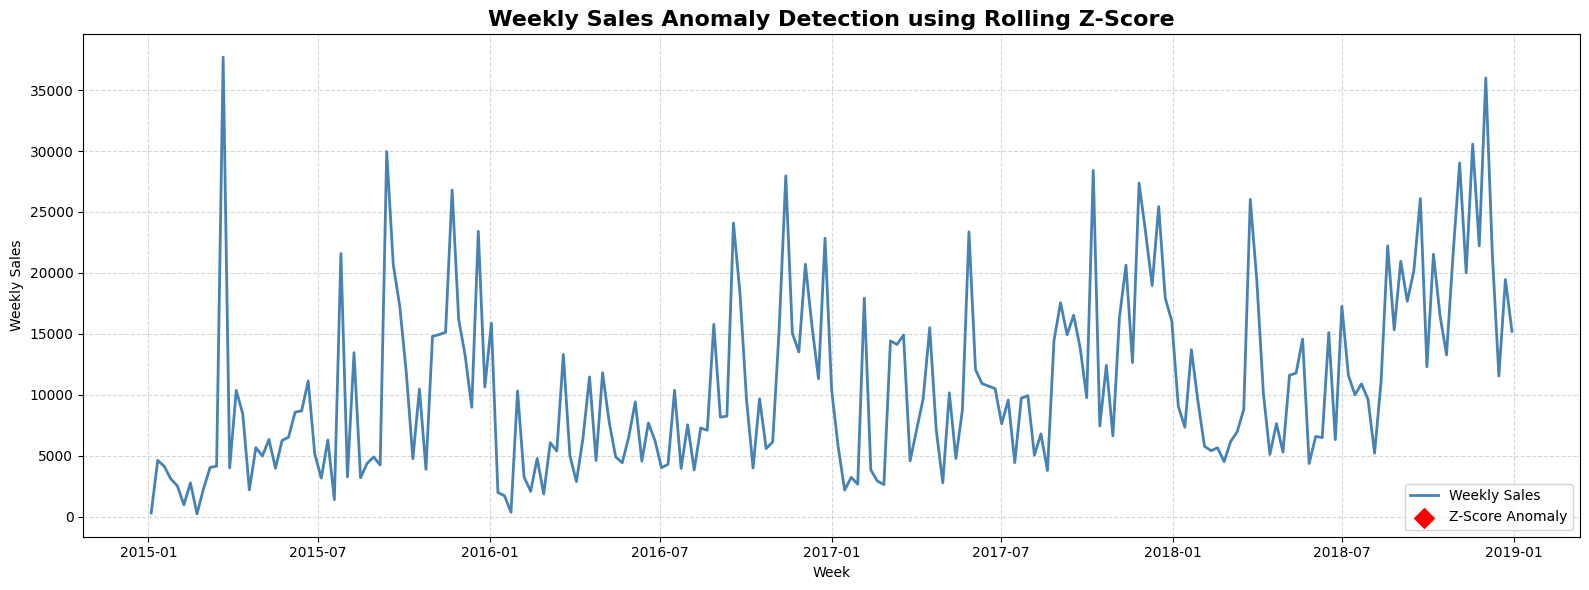

In [246]:
# Plot the Anomalies

plt.figure(figsize=(16,6))

# Weekly sales line
plt.plot(
    weekly_zscore["Order Date"],
    weekly_zscore["Sales"],
    color="steelblue",
    linewidth=2,
    label="Weekly Sales"
)

# Highlight anomalies
plt.scatter(
    zscore_anomalies["Order Date"],
    zscore_anomalies["Sales"],
    color="red",
    marker="D",
    s=100,
    label="Z-Score Anomaly"
)

plt.title("Weekly Sales Anomaly Detection using Rolling Z-Score",
          fontsize=16,
          fontweight="bold")
plt.xlabel("Week")
plt.ylabel("Weekly Sales")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("charts/Weekly_Sales_Anomaly_Detection_using_Rolling_Z-Score.png")
plt.show()

In [247]:
# Number of Anomalies

print("Total Weekly Observations:", len(weekly_zscore))
print("Z-Score Anomalies:", len(zscore_anomalies))

Total Weekly Observations: 209
Z-Score Anomalies: 0


Using the rolling Z-score method with a 4-week rolling window and a threshold of ±2 standard deviations, **no weekly sales observations were identified as anomalies**. This suggests that although weekly sales fluctuate over time, they remain within the expected range relative to the recent local sales pattern. Compared with Isolation Forest, the rolling Z-score method is more conservative for this dataset.

## Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you? 

The two anomaly detection methods produced different results. Isolation Forest identified several weeks as anomalous, whereas the Rolling Z-Score method did not flag any weeks using the ±2 standard deviation threshold. This disagreement suggests that Isolation Forest is more sensitive to unusual patterns because it uses a machine learning approach that considers how isolated each observation is relative to the rest of the data. In contrast, the Rolling Z-Score compares each week's sales only with its recent rolling mean and standard deviation. Since the weekly sales did not exceed two standard deviations from the local average, no anomalies were detected by the statistical method.

This comparison demonstrates that different anomaly detection techniques can produce different results depending on their underlying assumptions. Isolation Forest is better suited for detecting complex or irregular anomalies, while the Rolling Z-Score is more conservative and is most effective for identifying extreme deviations in normally distributed data.

## Task 6 — Product Demand Segmentation using Clustering

## Aggregate data at the product sub-category level with features like:

###  ○ Total sales volume 

In [248]:
# Total sales by Sub-Category
total_sales = (
    dataset.groupby("Sub-Category")["Sales"]
      .sum()
      .rename("Total_Sales")
)

total_sales

Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Chairs         322822.7310
Copiers        146248.0940
Envelopes       16128.0460
Fasteners        3001.9600
Furnishings     89212.0180
Labels          12347.7260
Machines       189238.6310
Paper           76828.3040
Phones         327782.4480
Storage        219343.3920
Supplies        46420.3080
Tables         202810.6280
Name: Total_Sales, dtype: float64

### ○ Sales growth rate (year-over-year) 

In [249]:
# Extract Year
dataset["Year"] = dataset["Order Date"].dt.year

yearly_sales = (
    dataset.groupby(["Sub-Category", "Year"])["Sales"]
      .sum()
      .reset_index()
)

yearly_sales

,Sub-Category,Year,Sales
0,Accessories,2015,23766.3960
1,Accessories,2016,40443.9700
2,Accessories,2017,41735.3640
3,Accessories,2018,58240.9700
4,Appliances,2015,15160.7150
...,...,...,...
63,Supplies,2018,15952.1100
64,Tables,2015,45757.7775
65,Tables,2016,35397.1955
66,Tables,2017,60762.1125


In [250]:
yearly_sales["YoY_Growth"] = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
)

yearly_sales["YoY_Growth"]

0          NaN
1     0.701729
2     0.031930
3     0.395482
4          NaN
        ...   
63    0.120071
64         NaN
65   -0.226422
66    0.716580
67    0.002163
Name: YoY_Growth, Length: 68, dtype: float64

In [251]:
growth_rate = (
    yearly_sales.groupby("Sub-Category")["YoY_Growth"]
    .mean()
    .fillna(0)
    .rename("Sales_Growth")
)

growth_rate

Sub-Category
Accessories    0.376381
Appliances     0.399276
Art            0.166056
Binders        0.218736
Bookcases      0.238065
Chairs         0.071358
Copiers        0.846718
Envelopes     -0.027666
Fasteners      0.157034
Furnishings    0.287889
Labels         0.121927
Machines       0.080060
Paper          0.254131
Phones         0.123409
Storage        0.131799
Supplies       1.928448
Tables         0.164107
Name: Sales_Growth, dtype: float64

### ○ Sales volatility (standard deviation of monthly sales)

In [252]:
monthly_sales = (
    dataset.groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="ME")
    ])["Sales"]
    .sum()
    .reset_index()
)

monthly_sales

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490
...,...,...,...
777,Tables,2018-08-31,4137.738
778,Tables,2018-09-30,5498.177
779,Tables,2018-10-31,11410.776
780,Tables,2018-11-30,13658.688


In [253]:
volatility = (
    monthly_sales.groupby("Sub-Category")["Sales"]
    .std()
    .fillna(0)
    .rename("Sales_Volatility")
)

volatility

Sub-Category
Accessories    2579.994809
Appliances     1821.621539
Art             330.488343
Binders        3848.223648
Bookcases      2220.405080
Chairs         4407.232960
Copiers        5500.774391
Envelopes       228.218688
Fasteners        48.742229
Furnishings    1360.017867
Labels          223.471218
Machines       5603.554747
Paper          1024.824982
Phones         4052.718221
Storage        2822.084310
Supplies       2025.094139
Tables         3224.082504
Name: Sales_Volatility, dtype: float64

### ○ Average order value 

In [254]:
average_order = (
    dataset.groupby("Sub-Category")["Sales"]
    .mean()
    .rename("Average_Order_Value")
)

average_order

Sub-Category
Accessories     217.178175
Appliances      227.926804
Art              34.019631
Binders         134.067550
Bookcases       503.598224
Chairs          531.833165
Copiers        2215.880212
Envelopes        65.032444
Fasteners        14.027850
Furnishings      95.823865
Labels           34.587468
Machines       1645.553313
Paper            57.420257
Phones          374.180877
Storage         263.633885
Supplies        252.284283
Tables          645.893720
Name: Average_Order_Value, dtype: float64

In [255]:
cluster_df = pd.concat([
    total_sales,
    growth_rate,
    volatility,
    average_order
], axis=1)

cluster_df

,Total_Sales,Sales_Growth,Sales_Volatility,Average_Order_Value
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
Chairs,322822.7310,0.071358,4407.232960,531.833165
Copiers,146248.0940,0.846718,5500.774391,2215.880212
Envelopes,16128.0460,-0.027666,228.218688,65.032444
Fasteners,3001.9600,0.157034,48.742229,14.027850


In [256]:
cluster_df = cluster_df.fillna(0)

In [257]:

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_df)

##  Use the Elbow Method to find the optimal number of clusters 

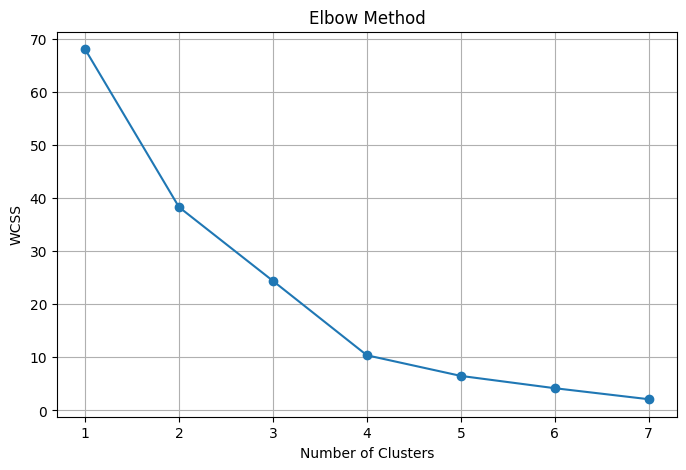

In [258]:
wcss = []

for k in range(1, 8):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,8), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

##  Apply K-Means Clustering to segment products into demand groups 

In [259]:
# Apply K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_df["Demand_Group"] = kmeans.fit_predict(scaled_features)

cluster_df.head()

,Total_Sales,Sales_Growth,Sales_Volatility,Average_Order_Value,Demand_Group
Sub-Category,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2
Appliances,104618.4030,0.399276,1821.621539,227.926804,1
Art,26705.4100,0.166056,330.488343,34.019631,1
Binders,200028.7850,0.218736,3848.223648,134.067550,2
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1


In [260]:
# Average sales in each cluster
cluster_summary = cluster_df.groupby("Demand_Group")["Total_Sales"].mean()

print(cluster_summary)

Demand_Group
0    167743.362500
1     54341.708189
2    239495.780667
Name: Total_Sales, dtype: float64


## Label each cluster meaningfully 

In [261]:
mapping = {
    0: "High Demand",
    2: "Medium Demand",
    1: "Low Demand"
}

cluster_df["Demand_Group"] = cluster_df["Demand_Group"].map(mapping)

In [262]:
cluster_df.sort_values("Demand_Group")

,Total_Sales,Sales_Growth,Sales_Volatility,Average_Order_Value,Demand_Group
Sub-Category,,,,,
Copiers,146248.0940,0.846718,5500.774391,2215.880212,High Demand
Machines,189238.6310,0.080060,5603.554747,1645.553313,High Demand
Fasteners,3001.9600,0.157034,48.742229,14.027850,Low Demand
Appliances,104618.4030,0.399276,1821.621539,227.926804,Low Demand
Art,26705.4100,0.166056,330.488343,34.019631,Low Demand
Bookcases,113813.1987,0.238065,2220.405080,503.598224,Low Demand
Envelopes,16128.0460,-0.027666,228.218688,65.032444,Low Demand
Supplies,46420.3080,1.928448,2025.094139,252.284283,Low Demand
Furnishings,89212.0180,0.287889,1360.017867,95.823865,Low Demand


In [263]:
cluster_df["Demand_Group"].value_counts()

Demand_Group
Low Demand       9
Medium Demand    6
High Demand      2
Name: count, dtype: int64

## Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed) 

In [264]:
# Reduce to 2 dimensions
pca = PCA(n_components=2, random_state=42)

pca_features = pca.fit_transform(scaled_features)

# Create DataFrame
pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1", "PC2"],
    index=cluster_df.index
)

# Add cluster labels
pca_df["Cluster"] = cluster_df["Demand_Group"]

pca_df.head()

,PC1,PC2,Cluster
Sub-Category,,,
Accessories,0.032855,-0.128039,Medium Demand
Appliances,-0.562213,0.137443,Low Demand
Art,-1.728503,-0.152657,Low Demand
Binders,0.617483,-0.594676,Medium Demand
Bookcases,-0.119791,-0.064887,Low Demand


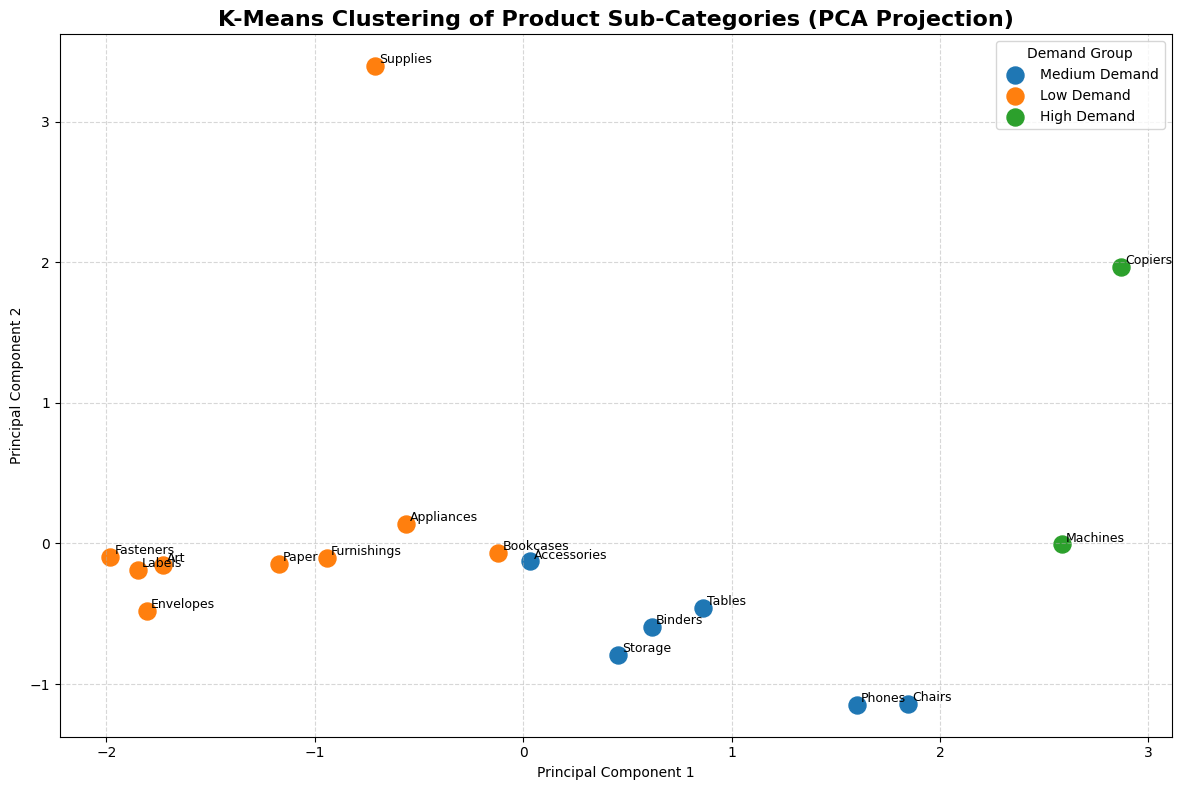

In [267]:
plt.figure(figsize=(12,8))

# Assign colors automatically
for cluster in pca_df["Cluster"].unique():

    subset = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=150,
        label=cluster
    )

# Label each point with its sub-category
for idx in pca_df.index:
    plt.text(
        pca_df.loc[idx, "PC1"] + 0.02,
        pca_df.loc[idx, "PC2"] + 0.02,
        idx,
        fontsize=9
    )

plt.title(
    "K-Means Clustering of Product Sub-Categories (PCA Projection)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Demand Group")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("charts/K-Means_Clustering_of_Product_Sub-Categories_(PCA Projection).png")
plt.show()

K-Means clustering was applied to group product sub-categories based on **Total Sales, Year-over-Year Sales Growth, Sales Volatility, and Average Order Value**. After standardizing the features, the Elbow Method was used to select the number of clusters, and the resulting clusters were interpreted as **High Demand, Medium Demand, and Low Demand** groups.

- **High Demand: High sales volume and higher average order values, representing the most valuable product sub-categories.**
- **Medium Demand: Moderate sales and stable demand, indicating products with consistent performance.**
- **Low Demand: Lower sales volume and lower average order values, suggesting products that may require promotional efforts or inventory optimization.**

PCA was used to reduce the four-dimensional feature space **(Total Sales, Sales Growth Rate, Sales Volatility, and Average Order Value)** into two principal components for visualization. The scatter plot shows how product sub-categories are grouped by K-Means clustering. Sub-categories within the same cluster exhibit similar sales characteristics, while those in different clusters have distinct demand patterns. The visualization confirms that K-Means successfully segmented the products into meaningful demand groups, which can support inventory planning, pricing decisions, and targeted marketing strategies.

## Write: what stocking strategy would you recommend for each cluster? 

Based on the K-Means clustering results, products in the **High Demand** cluster should receive the highest inventory priority to prevent stock shortages and maximize revenue. **Medium Demand** products should be managed with balanced stock levels and periodic monitoring to adapt to seasonal changes. **Low Demand** products should be stocked conservatively to reduce inventory carrying costs, while promotional strategies or product rationalization can be considered to improve their performance. This demand-based stocking strategy helps optimize inventory, reduce storage costs, and improve customer satisfaction by ensuring that high-demand products remain readily available.